# Objectif du notebook 

Date de création : 17/09/2025

L'objectif du notebook est de reprendre l'analyse des données Fiberscope afin de s'assurer de la comformité des résultats obtenus avec la méthode RTF-MFP et d'éliminer toutes les zones d'ombre possibles. 

Pour ce faire, l'analyse s'articule en plusieurs étapes : 

## Etape 1 : choix de la taille des fenêtres STFT utilisée (paramètre $n_{stft}$)

Cette première étape est essentielle afin d'assurer les performances de la méthode MFP-RTF. Plusieurs approches sont possibles : 

* Approche 1 : minimisation de la distance au vecteur de RTF estimé par déconvolution. 
* Approche 2 : hypothèse propagation longue distance et estimation de la durée de la durée de la réponse impulsionnelle à l'aide de la vitesse de groupe minimale sur la bande de fréquence. 



In [2]:
import os 
import sys 
import numpy as np 
import xarray as xr
import scipy.signal as sp
import matplotlib.pyplot as plt  
sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

import params as p
from scipy.optimize import least_squares
from fiberscope_manager import FiberscopeManager
from fiberscope_recording import FiberscopeSweep1, FiberscopeSweep2

from propa.rtf.rtf_utils import D_hermitian_angle_fast

In [3]:
# Useful properties
h_index_ref = 5

# Flags 
run_static_demo = False

### Première illustration avec le paramètre par défaut 

In [4]:
# Load and preprocess static record
fs_sweep = FiberscopeSweep1()
# fs_sweep = FiberscopeSweep2()
# 
records_to_process = fs_sweep.records_N1
# records_to_process = fs_sweep.records_N1 + fs_sweep.records_N3 + fs_sweep.records_N5
fs_sweep.records_folder = os.path.join(p.root_data, "static")
if not os.path.exists(fs_sweep.records_folder):
    os.makedirs(fs_sweep.records_folder)

if run_static_demo:
    fsm = FiberscopeManager(
        root_processed_data=p.root_data, h_index_ref=h_index_ref, plot_feature=True
    )
    fsm.process_static_analysis(
        static_signal=fs_sweep,
        static_records_names=records_to_process,
    )

In [5]:
dist_func = D_hermitian_angle_fast
ax_f = 1
ax_rcv = 0
dist_kwargs = {
    "ax_f": ax_f,
    "unit": "deg",
    "ax_rcv": ax_rcv,
    "apply_mean": True,
    "apply_median": False,
}


In [6]:
# Compare RTF estimated by deconvolution and by CS-EVD
for record_name in records_to_process:
    ds_rtf_fpath = os.path.join(p.root_data, "static", f"{record_name}_rtf.nc")
    ds_rtf = xr.open_dataset(ds_rtf_fpath)

    # Build RTF ref (from deconvolution)
    rtf_ref = ds_rtf.rtf_amp * np.exp(1j*ds_rtf.rtf_phase)

    # Build RTF hat (from CS-EVD)
    rtf_hat = ds_rtf.rtf_amp_hat * np.exp(1j * ds_rtf.rtf_phase_hat)

    # Interp RTF ref at RTF hat frequencies (nearest neigbor) 
    rtf_ref = rtf_ref.sel(f_ir=rtf_hat.f_rtf.values, method="nearest")

    # Compute mean theta distance over the frequency band of interest 
    theta = dist_func(rtf_ref=rtf_ref.values, rtf=rtf_hat.values, **dist_kwargs)

    print(f"Record: {record_name}")
    print(theta)       
 

Record: 09-10-2024T10-34-58-394627_P1_N1_Sweep_34
39.74919664853792
Record: 09-10-2024T16-51-22-900122_P2_N1_Sweep_93
39.233102650516585
Record: 10-10-2024T09-43-06-620681_P3_N1_Sweep_151
43.77731825256812
Record: 10-10-2024T12-03-02-201689_P4_N1_Sweep_211
39.80202256774591
Record: 10-10-2024T14-42-01-833325_P5_N2_Sweep_267
49.12510882196309
Record: 10-10-2024T15-54-25-737795_P6_N1_Sweep_323
38.38330513569948


In [7]:
# Compare RTF estimated by deconvolution and by CS-EVD on a restricted frequency band
fmin = 10 * 1e3  # Hz
fmax = 11 * 1e3  # Hz
print(f"Frequency band: [{fmin/1e3}, {fmax/1e3}] kHz")

Frequency band: [10.0, 11.0] kHz


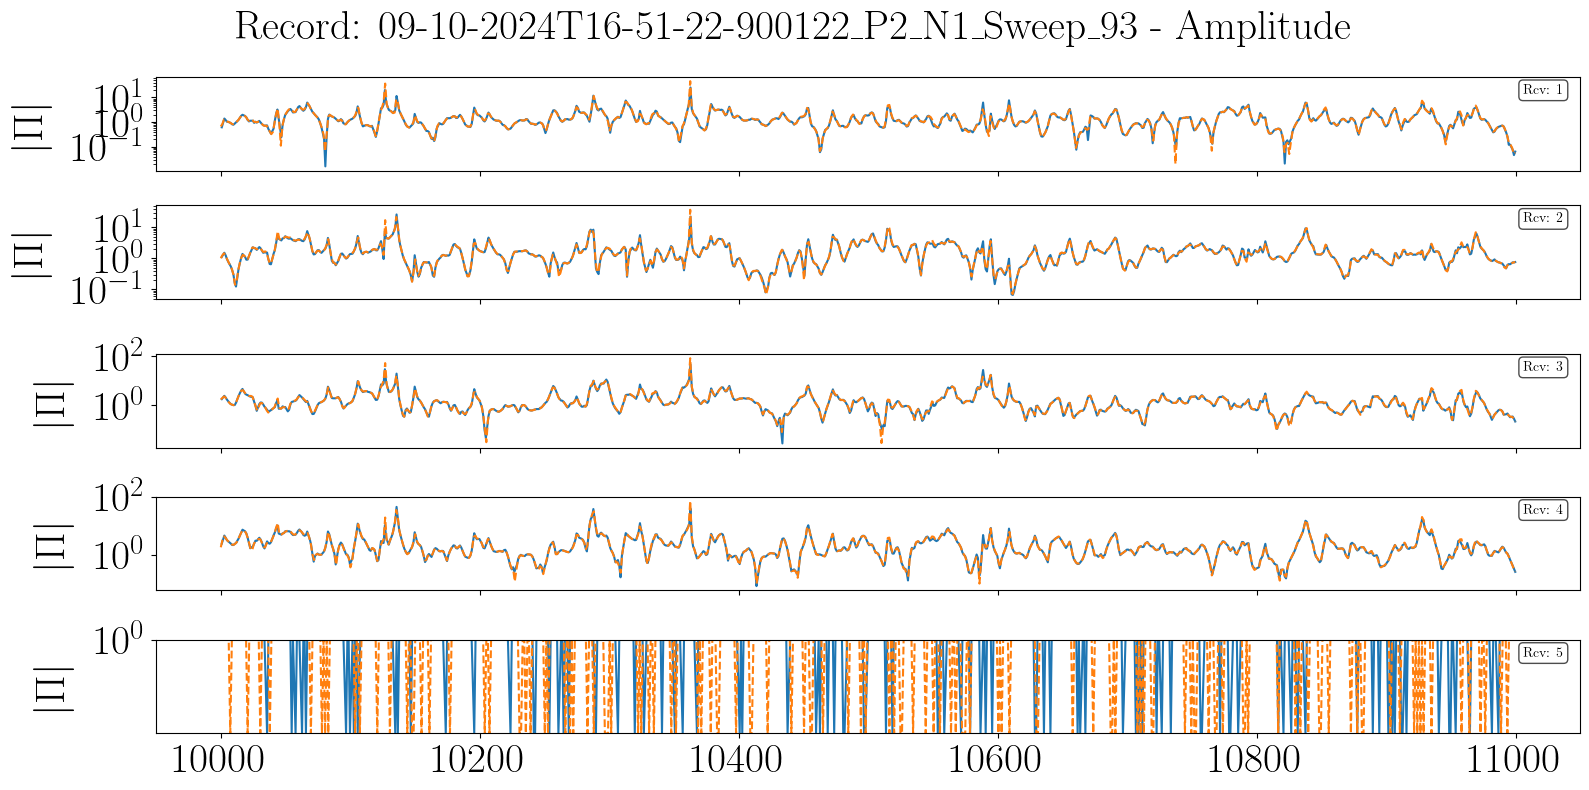

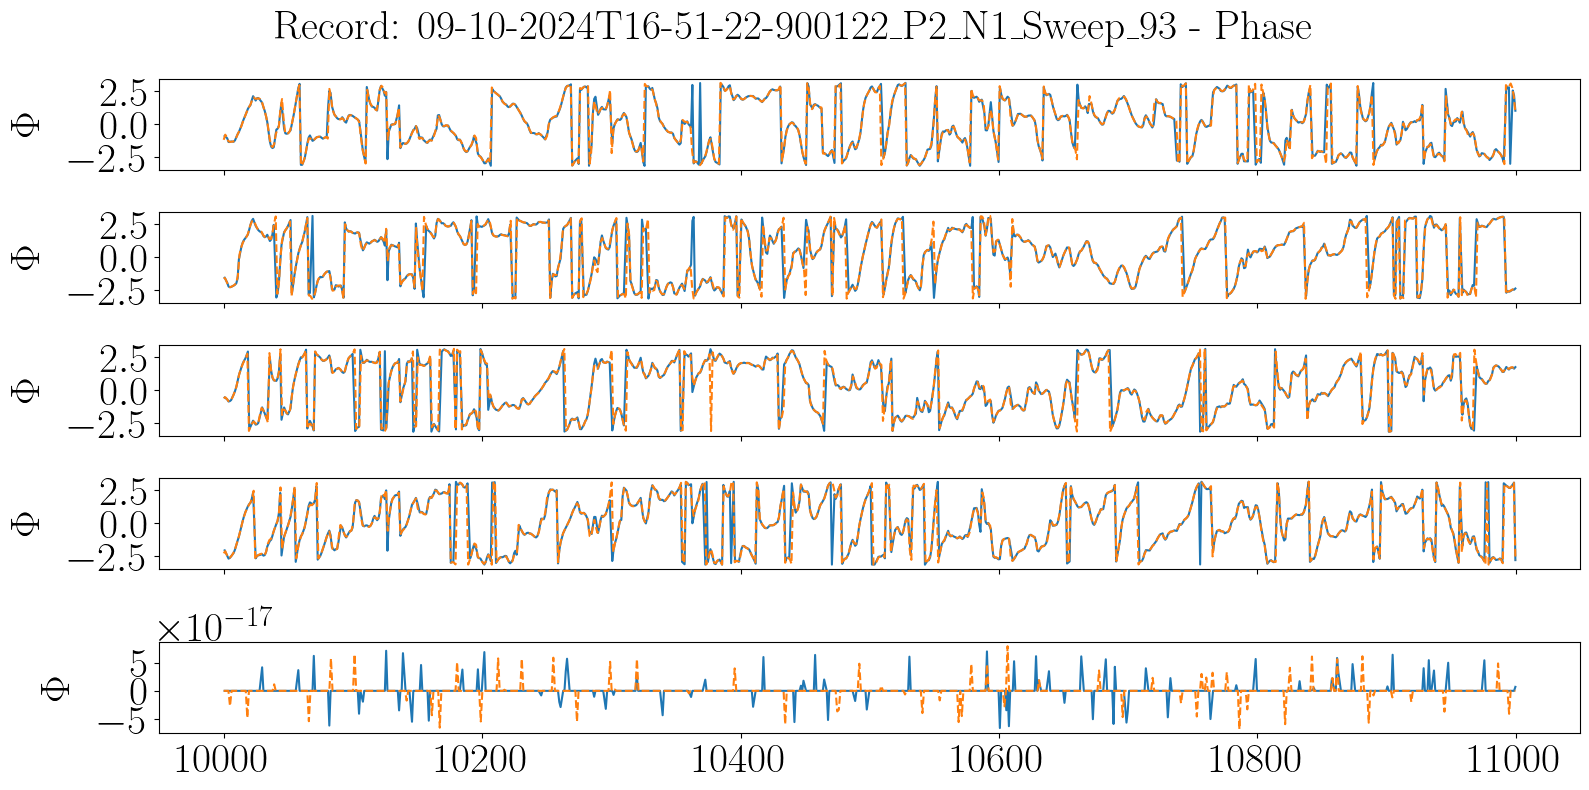

In [8]:
# Plot RTF ref and RTF hat on the frequency band of interest
records_to_plot = records_to_process[1:2]

for record_name in records_to_plot:

    # Load data
    ds_rtf_fpath = os.path.join(p.root_data, "static", f"{record_name}_rtf.nc")
    ds_rtf = xr.open_dataset(ds_rtf_fpath)

    nl = ds_rtf.sizes["h_index"]
    fig_amp, axs_amp = plt.subplots(nl, 1, sharex=True)
    fig_amp.suptitle(f"Record: {record_name} - Amplitude")
    fig_phase, axs_phase = plt.subplots(nl, 1, sharex=True)
    fig_phase.suptitle(f"Record: {record_name} - Phase")
    # Plot for each receiver
    for i in range(nl):
        # Select receiver
        ds_rtf_rcv = ds_rtf.isel(h_index=i)
        # Select frequency band
        ds_rtf_rcv = ds_rtf_rcv.sel(f_ir=slice(fmin, fmax))
        ds_rtf_rcv = ds_rtf_rcv.sel(f_rtf=slice(fmin, fmax))

        # Extract RTF ref (from deconvolution)
        rtf_ref_mod = ds_rtf_rcv.rtf_amp
        rtf_ref_phase = ds_rtf_rcv.rtf_phase
        # Extract RTF hat (from CS-EVD)
        rtf_hat_mod = ds_rtf_rcv.rtf_amp_hat
        rtf_hat_phase = ds_rtf_rcv.rtf_phase_hat

        # Interp RTF ref at RTF hat frequencies (nearest neigbor)
        rtf_ref_mod = rtf_ref_mod.sel(f_ir=rtf_hat.f_rtf.values, method="nearest")
        rtf_ref_phase = rtf_ref_phase.sel(f_ir=rtf_hat.f_rtf.values, method="nearest")

        # Plot RTF mod
        rtf_ref_mod.plot(label=r"$|\Pi_{ref}|$", color="tab:blue", ax=axs_amp[i])
        rtf_hat_mod.plot(label=r"$|\hat{\Pi}|$", color="tab:orange", linestyle="--", ax=axs_amp[i])
        axs_amp[i].set_xlabel("")
        axs_amp[i].set_ylabel(r"$|\Pi|$")
        axs_amp[i].set_yscale("log")
        axs_amp[i].set_title("")
        # axs_amp[i].set_title(f"Record: {record_name}, Rcv: {ds_rtf_rcv.h_index.values}")
        # axs_amp[i].legend()

        # Add annotation for receiver index and record name
        axs_amp[i].annotate(
            f"Rcv: {ds_rtf_rcv.h_index.values}",
            xy=(0.96, 0.82),
            xycoords="axes fraction",
            fontsize=10,
            color="black",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
        )

        # Plot phase
        rtf_ref_phase.plot(label=r"$\Phi_{ref}$", color="tab:blue", ax=axs_phase[i])
        rtf_hat_phase.plot(
            label=r"$\hat{\Phi}$", color="tab:orange", linestyle="--", ax=axs_phase[i]
        )
        axs_phase[i].set_xlabel("")
        axs_phase[i].set_ylabel(r"$\Phi$")
        axs_phase[i].set_title("")
        # axs_phase[i].set_title(
        #     f"Record: {record_name}, Rcv: {ds_rtf_rcv.h_index.values}"
        # )
        # axs_phase[i].legend()

In [9]:

for record_name in records_to_process:
    ds_rtf_fpath = os.path.join(p.root_data, "static", f"{record_name}_rtf.nc")
    ds_rtf = xr.open_dataset(ds_rtf_fpath)

    ds_rtf = ds_rtf.sel(f_ir=slice(fmin, fmax))
    ds_rtf = ds_rtf.sel(f_rtf=slice(fmin, fmax))

    # Build RTF ref (from deconvolution)
    rtf_ref = ds_rtf.rtf_amp * np.exp(1j*ds_rtf.rtf_phase)

    # Build RTF hat (from CS-EVD)
    rtf_hat = ds_rtf.rtf_amp_hat * np.exp(1j * ds_rtf.rtf_phase_hat)

    # Interp RTF ref at RTF hat frequencies (nearest neigbor) 
    rtf_ref = rtf_ref.sel(f_ir=rtf_hat.f_rtf.values, method="nearest")

    # Compute mean theta distance over the frequency band of interest 
    theta = dist_func(rtf_ref=rtf_ref.values, rtf=rtf_hat.values, **dist_kwargs)

    # Compute modules and phases distance (euclidian distance)
    mod_dist = np.linalg.norm(np.abs(rtf_ref.values) - np.abs(rtf_hat.values), ord="fro")
    phase_dist = np.linalg.norm(np.angle(rtf_ref.values) - np.angle(rtf_hat.values), ord="fro")

    print(f"Record: {record_name}")
    print(f"Theta: {theta}, Module distance (Frobenius): {mod_dist}, Phase distance (Frobenius): {phase_dist}")       

    # Distance for each receiver
    mod_dist_by_rcv = np.linalg.norm(np.abs(rtf_ref.values) - np.abs(rtf_hat.values), axis=1)
    phase_dist_by_rcv = np.linalg.norm(np.angle(rtf_ref.values) - np.angle(rtf_hat.values), axis=1)
    for i, d in enumerate(mod_dist_by_rcv):
        print(f"rcv {i+1}:  mod = {d}, phase = {phase_dist_by_rcv[i]}")

 

Record: 09-10-2024T10-34-58-394627_P1_N1_Sweep_34
Theta: 16.592656960143454, Module distance (Frobenius): 23.757479814920583, Phase distance (Frobenius): 44.48418803616798
rcv 1:  mod = 10.870122102294456, phase = 21.354949064141636
rcv 2:  mod = 13.406524953095284, phase = 27.258606231441885
rcv 3:  mod = 10.587274426686491, phase = 16.628853237305346
rcv 4:  mod = 12.42710752885129, phase = 22.433429564746096
rcv 5:  mod = 1.538370149106851e-15, phase = 5.123389180215164e-16
Record: 09-10-2024T16-51-22-900122_P2_N1_Sweep_93
Theta: 30.63018199478223, Module distance (Frobenius): 68.35399731487799, Phase distance (Frobenius): 46.82493501644521
rcv 1:  mod = 27.056073118465665, phase = 19.729089723572343
rcv 2:  mod = 19.958028813027237, phase = 26.3465559938335
rcv 3:  mod = 45.328332846119444, phase = 22.77533215169451
rcv 4:  mod = 38.56497353325126, phase = 24.299810505790674
rcv 5:  mod = 1.5700924586837751e-15, phase = 4.907303211900482e-16
Record: 10-10-2024T09-43-06-620681_P3_N1

### Réponses impulsionnelles calculées par déconvolution  

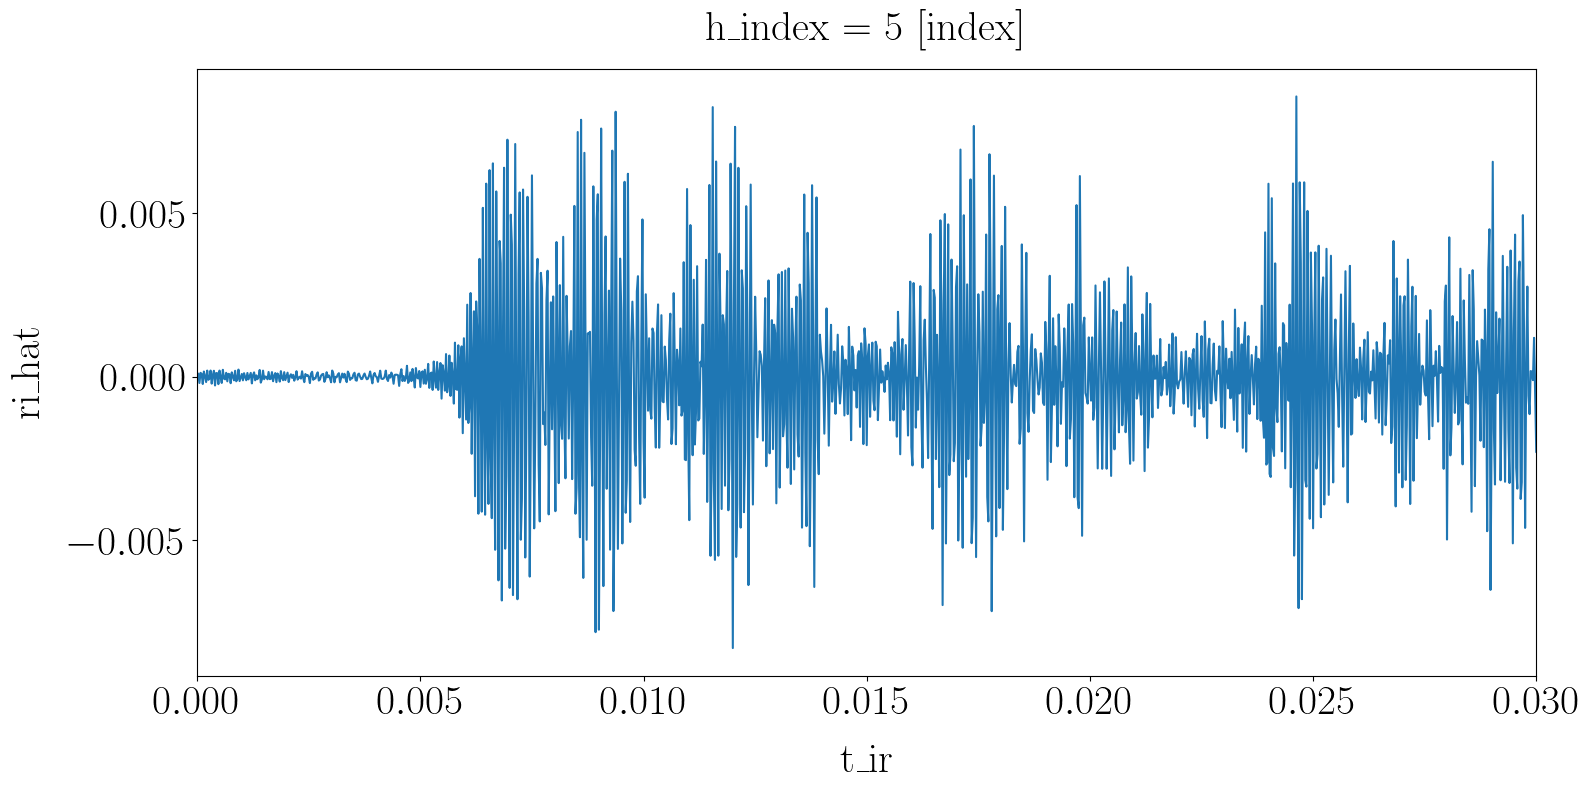

In [10]:
# Calcul des réponses impulsionnelles et analyse
records_to_plot = records_to_process[1:2]
nr = len(records_to_plot)
fig, axs = plt.subplots(nr, 1, sharex=True)
axs = np.atleast_1d(axs)
for irec, record_name in enumerate(records_to_plot):

    ds_rtf_fpath = os.path.join(p.root_data, "static", f"{record_name}_rtf.nc")
    ds_rtf = xr.open_dataset(ds_rtf_fpath)

    # Plot RIR
    # ds_rtf.ri_hat.plot(ax=axs[irec], label=f"Record {record_name}", hue="h_index")
    ds_rtf.ri_hat.sel(h_index=5).plot(ax=axs[irec], label=f"Record {record_name}", hue="h_index")

    axs[irec].set_xlim([0, 0.03])

## Positionnement des hydrophones 

### Détection des temps d'arrivées

In [122]:
# Calcul du temps d'arrivée pour le couple (P1, H1)
record_name = records_to_process[0]
print(f"Record to study: {record_name}")
idx_rcv_to_study = 5

ds_rtf_fpath = os.path.join(p.root_data, "static", f"{record_name}_rtf.nc")
ds_rtf = xr.open_dataset(ds_rtf_fpath)

sig = ds_rtf.signal.sel(h_index=idx_rcv_to_study)

Record to study: 09-10-2024T10-34-58-394627_P1_N1_Sweep_34


(0.0, 0.004)

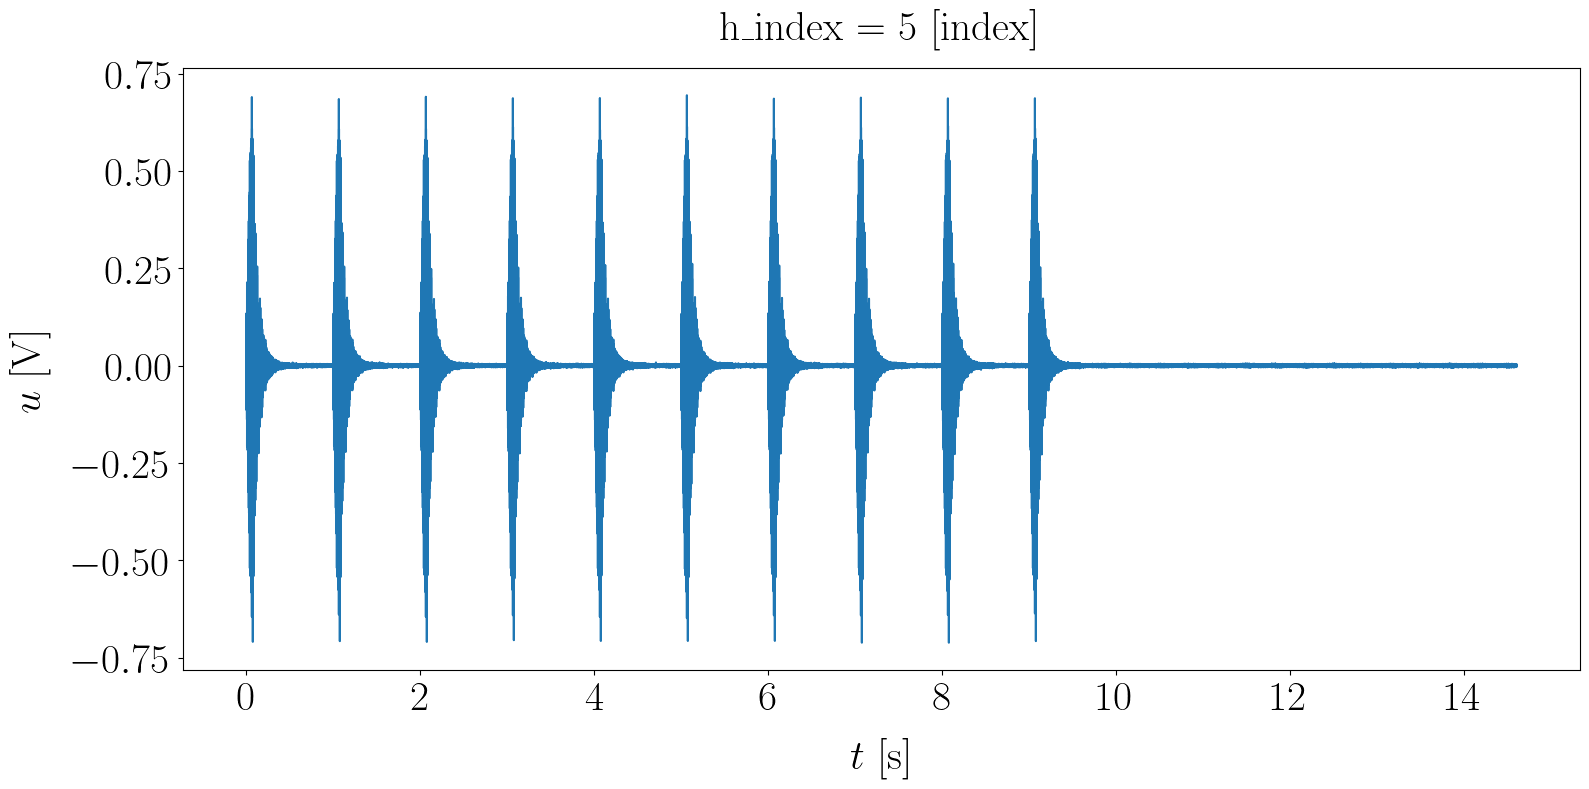

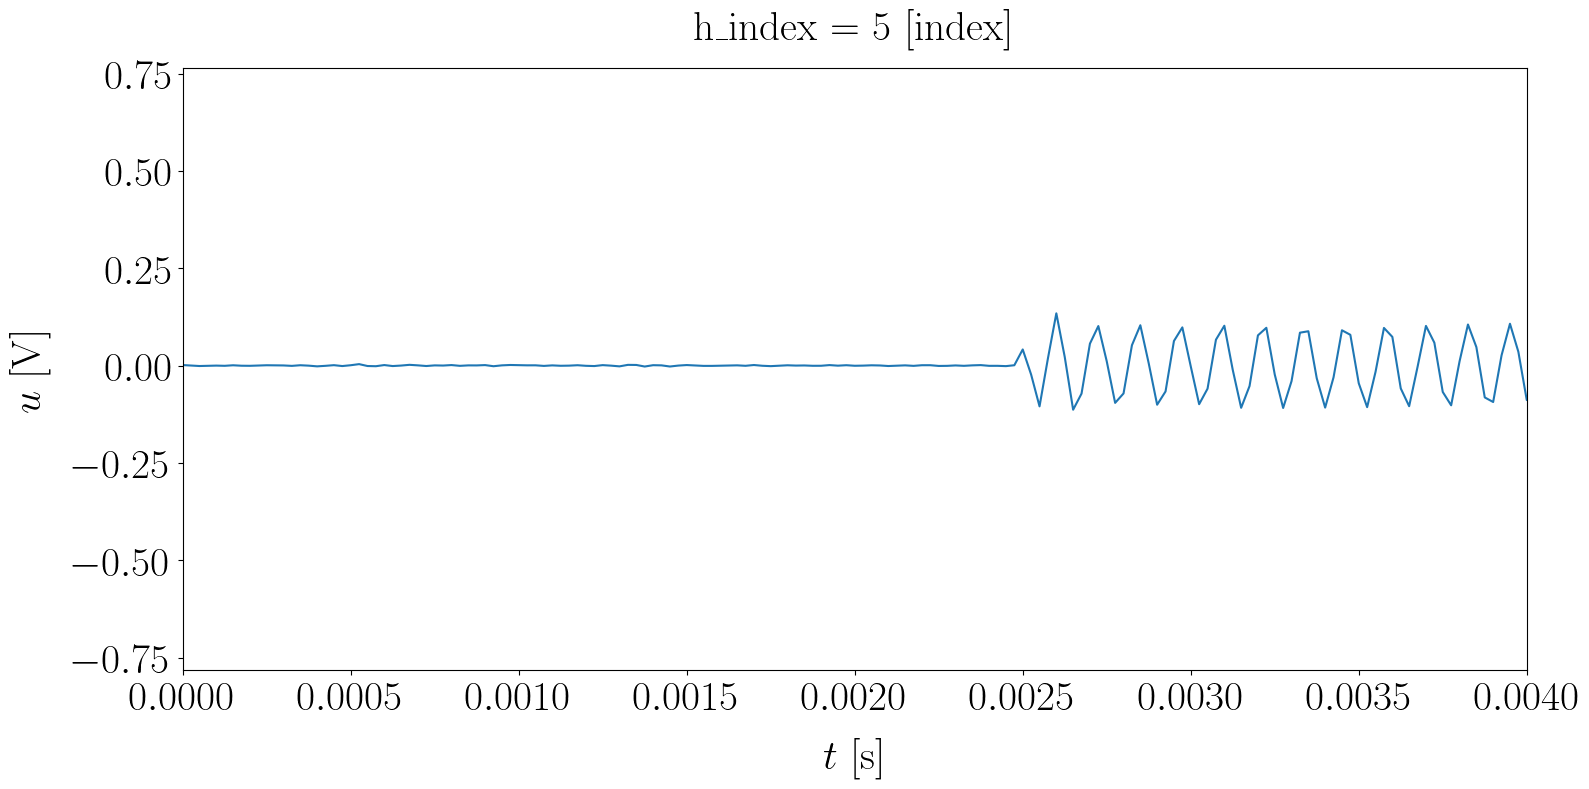

In [123]:
plt.figure()
sig.plot()
plt.figure()
sig.plot()
plt.xlim([0, 0.004])

In [124]:
# Calcul de l'enveloppe du signal
sig_h = sp.hilbert(sig)
sig_phase = np.angle(sig_h)
sig_env = np.abs(sig_h)

In [125]:
# On défini un seuil à 500 % du niveau de bruit
c0 = 1500
d_min = 2
td_min = d_min / c0
noise_lvl = sig_env[0 : int(td_min * fs)].max()
env_detection_th = 5 * noise_lvl

# Recherche du premier pic au dessus du seuil
idx_peak = np.where(sig_env > env_detection_th)[0][0]
# On définit un intervalle de reherche autour du pic 
delta_idx_peak = 10
idx_search_start = max(0, idx_peak - delta_idx_peak)
idx_search_stop = min(len(sig_env), idx_peak + delta_idx_peak)


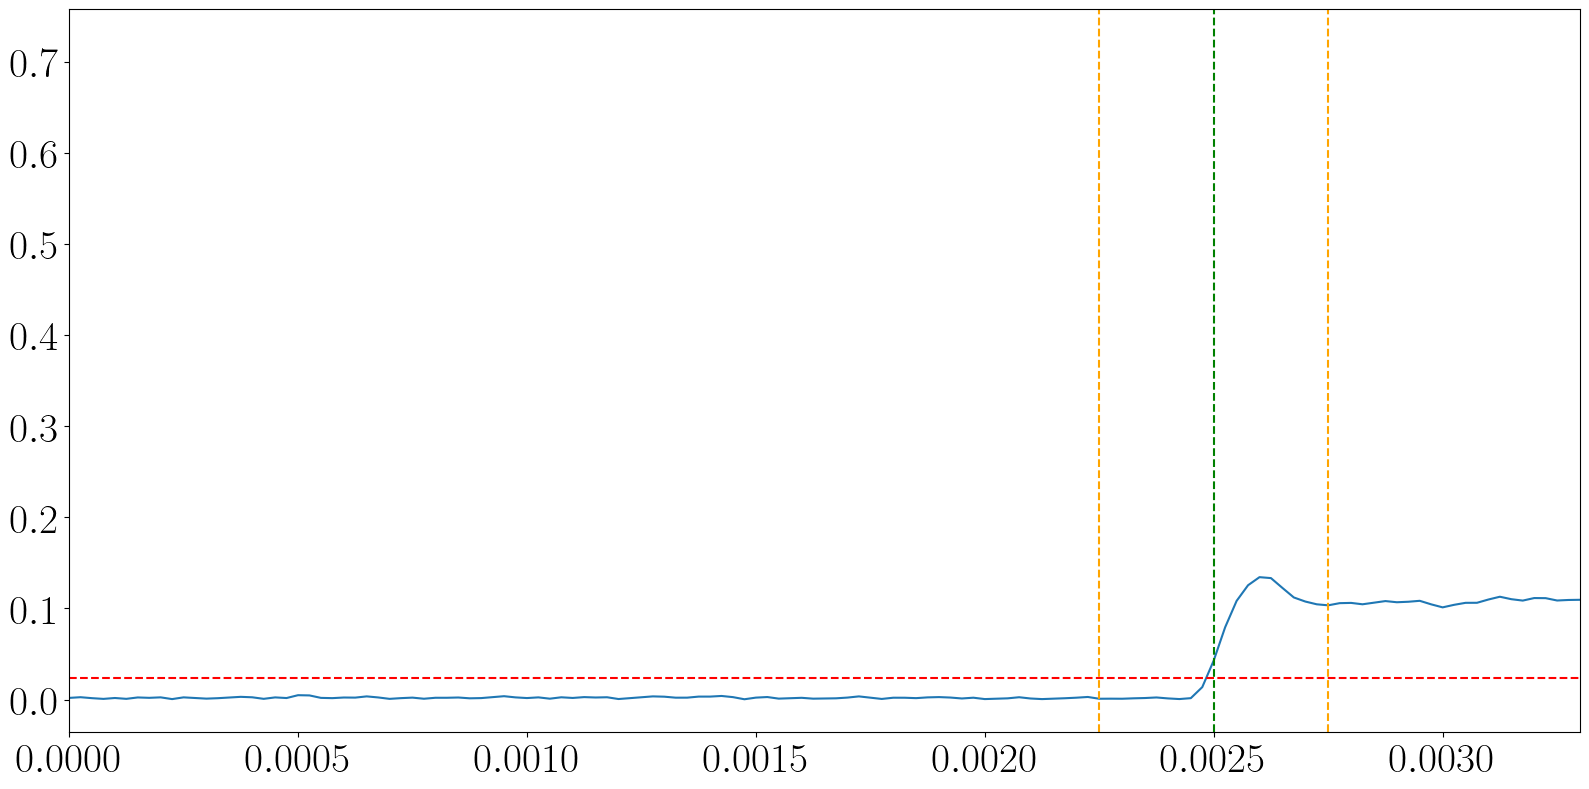

In [126]:
plt.figure()
plt.plot(sig.time, sig_env)
plt.axhline(env_detection_th, color="red", linestyle="--")
plt.xlim([0, sig.time[idx_search_stop]*1.2])
plt.axvline(sig.time[idx_peak], color="green", linestyle="--")
plt.axvline(sig.time[idx_search_start], color="orange", linestyle="--")
plt.axvline(sig.time[idx_search_stop], color="orange", linestyle="--")

In [127]:
# On calcul la dérivée de l'enveloppe pour trouver le maximum
ts = 1/fs
sig_env_deriv = np.gradient(sig_env, ts)
idx_peak_refined = np.argmax(sig_env_deriv[idx_search_start:idx_search_stop]) + idx_search_start
t_arrival = sig.time[idx_peak_refined]

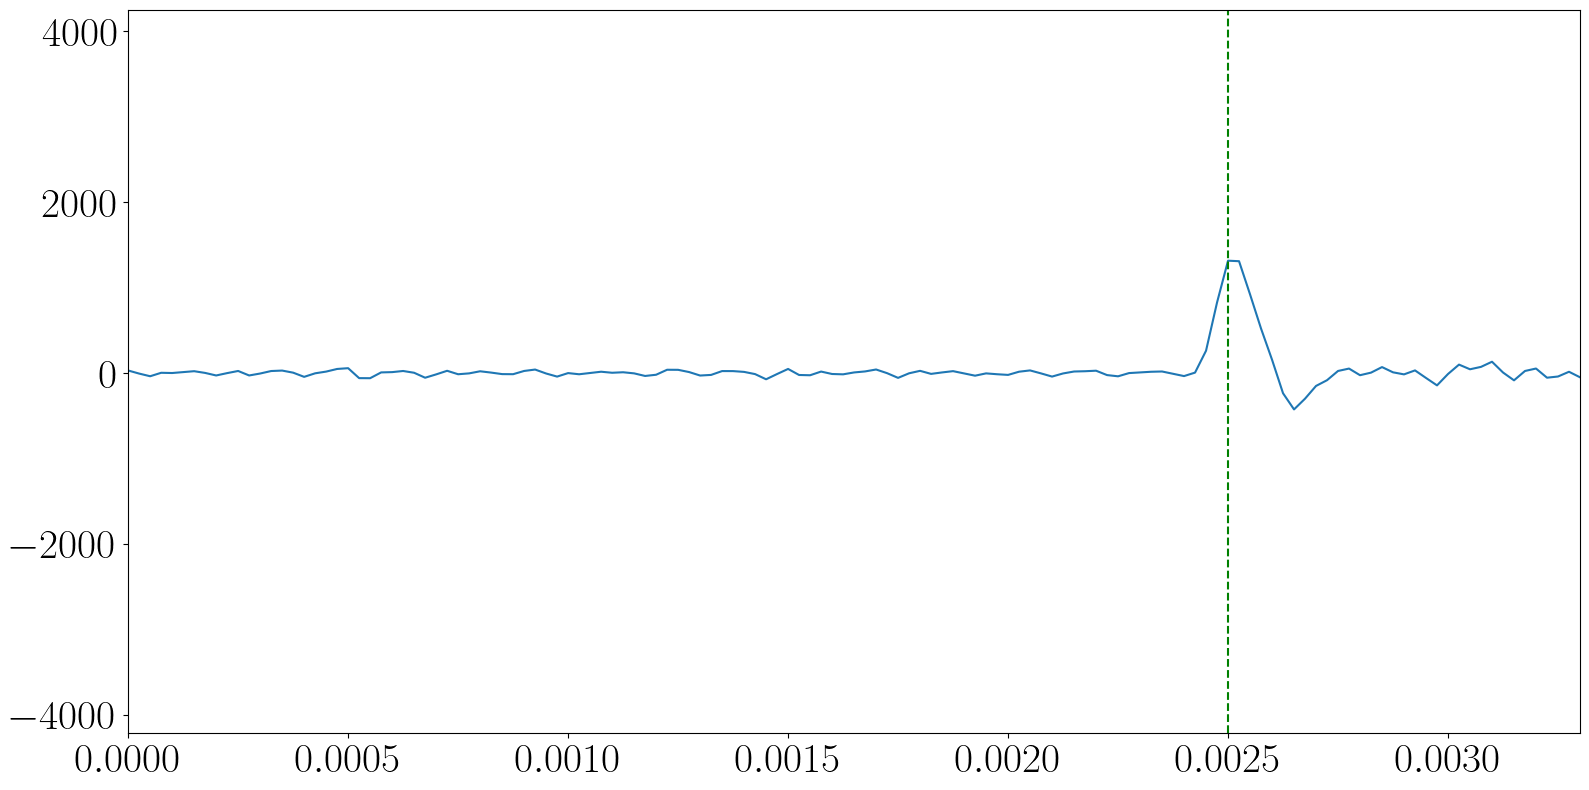

In [128]:
plt.figure()
plt.plot(sig.time, sig_env_deriv)
plt.xlim([0, sig.time[idx_search_stop]*1.2])
plt.axvline(sig.time[idx_peak_refined], color="green", linestyle="--")

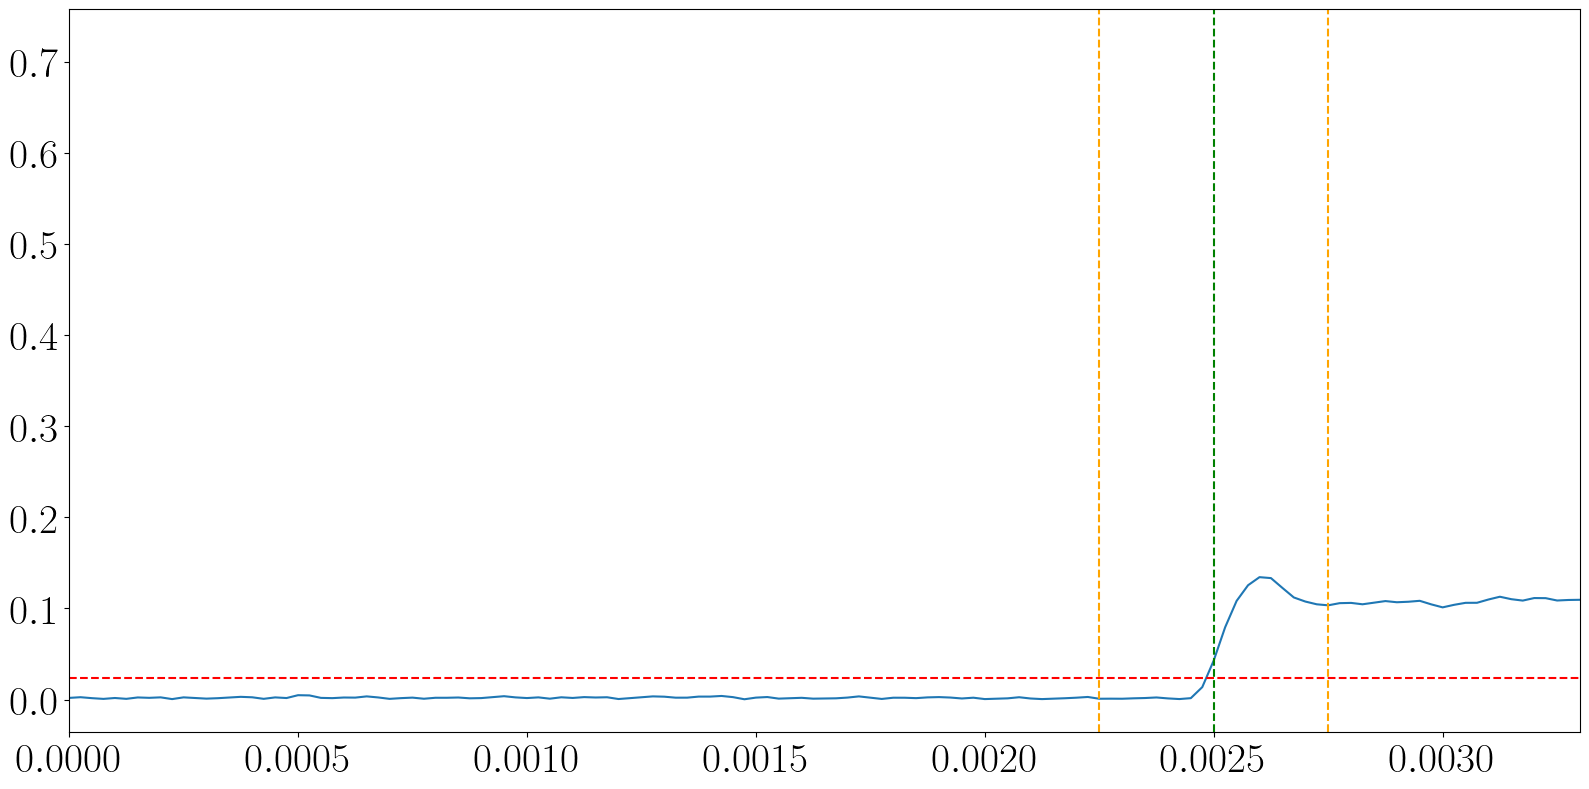

In [129]:
plt.figure()
plt.plot(sig.time, sig_env)
plt.axhline(env_detection_th, color="red", linestyle="--")
plt.xlim([0, sig.time[idx_search_stop] * 1.2])
# plt.axvline(sig.time[idx_peak], color="green", linestyle="--")
plt.axvline(sig.time[idx_peak_refined], color="green", linestyle="--")
plt.axvline(sig.time[idx_search_start], color="orange", linestyle="--")
plt.axvline(sig.time[idx_search_stop], color="orange", linestyle="--")

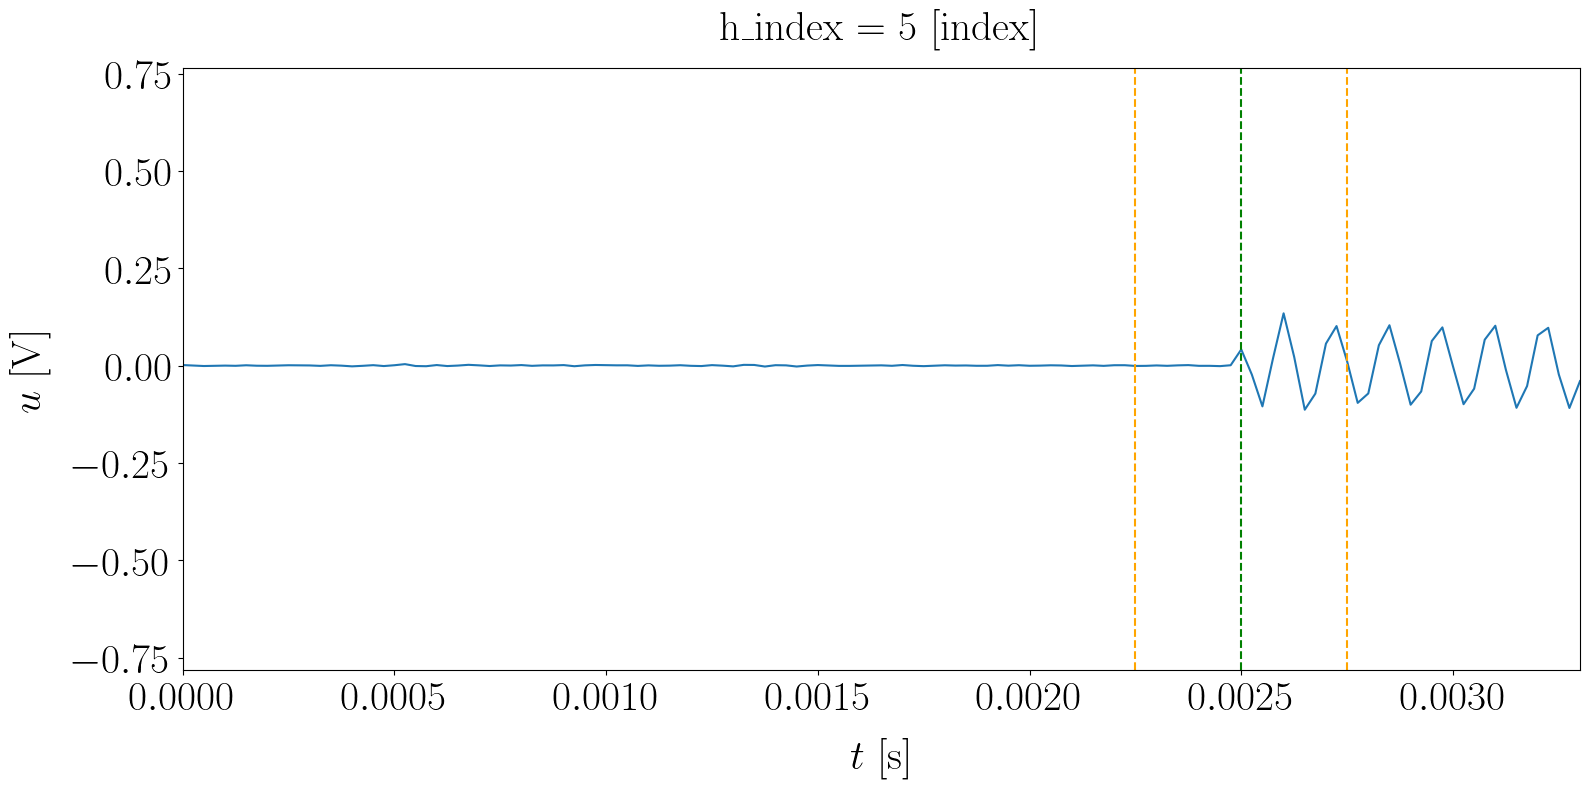

In [130]:
plt.figure()
sig.plot()
plt.xlim([0, sig.time[idx_search_stop] * 1.2])
# plt.axvline(sig.time[idx_peak], color="green", linestyle="--")
plt.axvline(sig.time[idx_peak_refined], color="green", linestyle="--")
plt.axvline(sig.time[idx_search_start], color="orange", linestyle="--")
plt.axvline(sig.time[idx_search_stop], color="orange", linestyle="--")

#### Approche la plus simple : détecteur d'énergie 

Text(0.5, 0, 'Time [sec]')

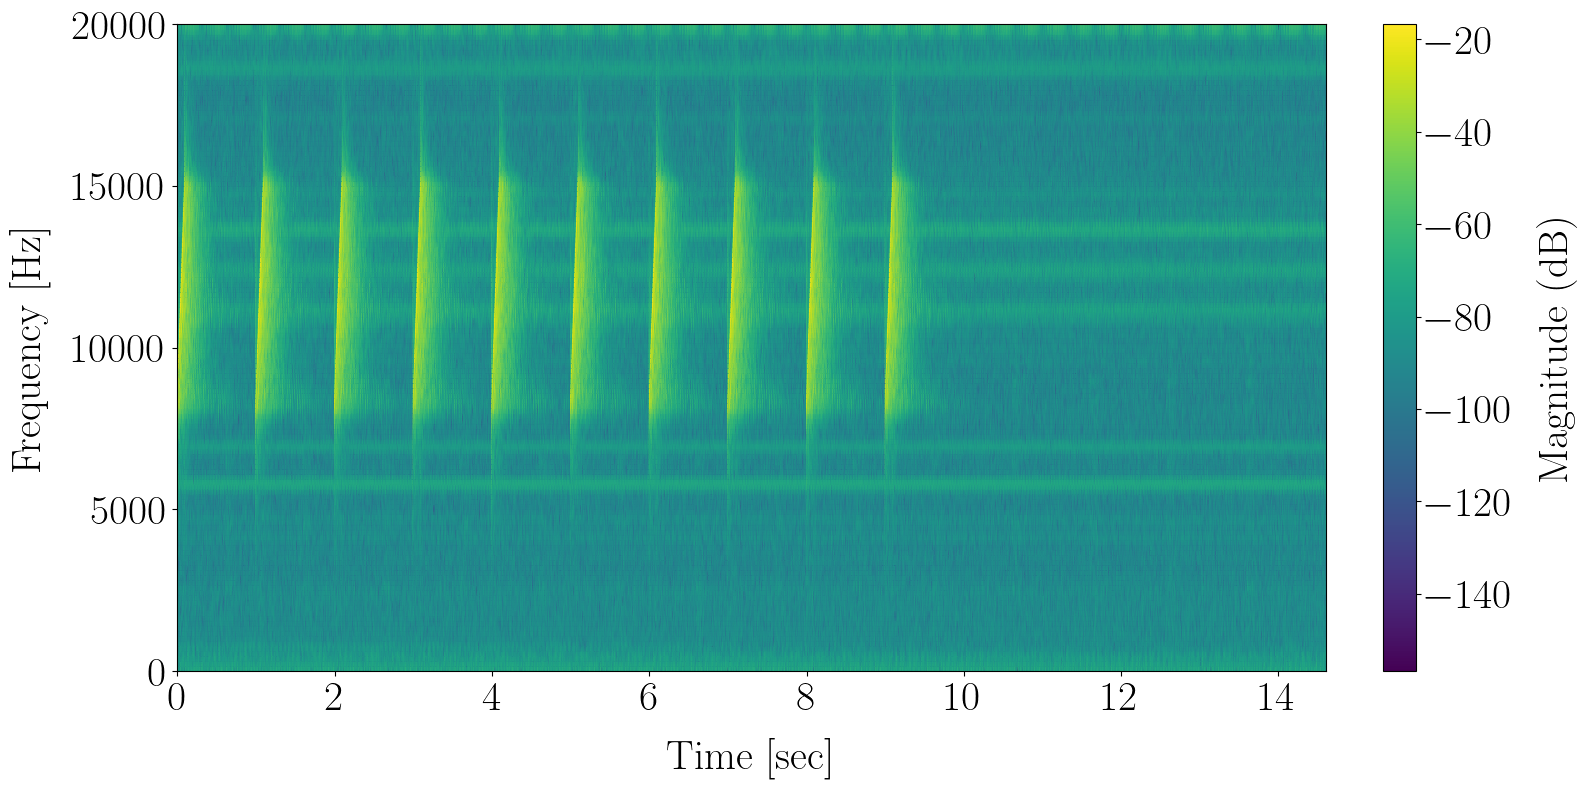

In [40]:
# Calcul de la STFT
fs = ds_rtf.fs
nperseg = 256
noverlap = nperseg // 2
f, t, Sxx = sp.stft(sig.values, fs=fs, nperseg=nperseg, noverlap=noverlap)

plt.figure()
plt.pcolormesh(t, f, 20 * np.log10(np.abs(Sxx)), shading="gouraud")
plt.colorbar(label="[dB]")
plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [s]")




Record to study: 09-10-2024T10-34-58-394627_P1_N1_Sweep_34
Time of arrival (direct) = 0.0004249999999999965 s
Distance (direct) = 0.6374999999999947 m


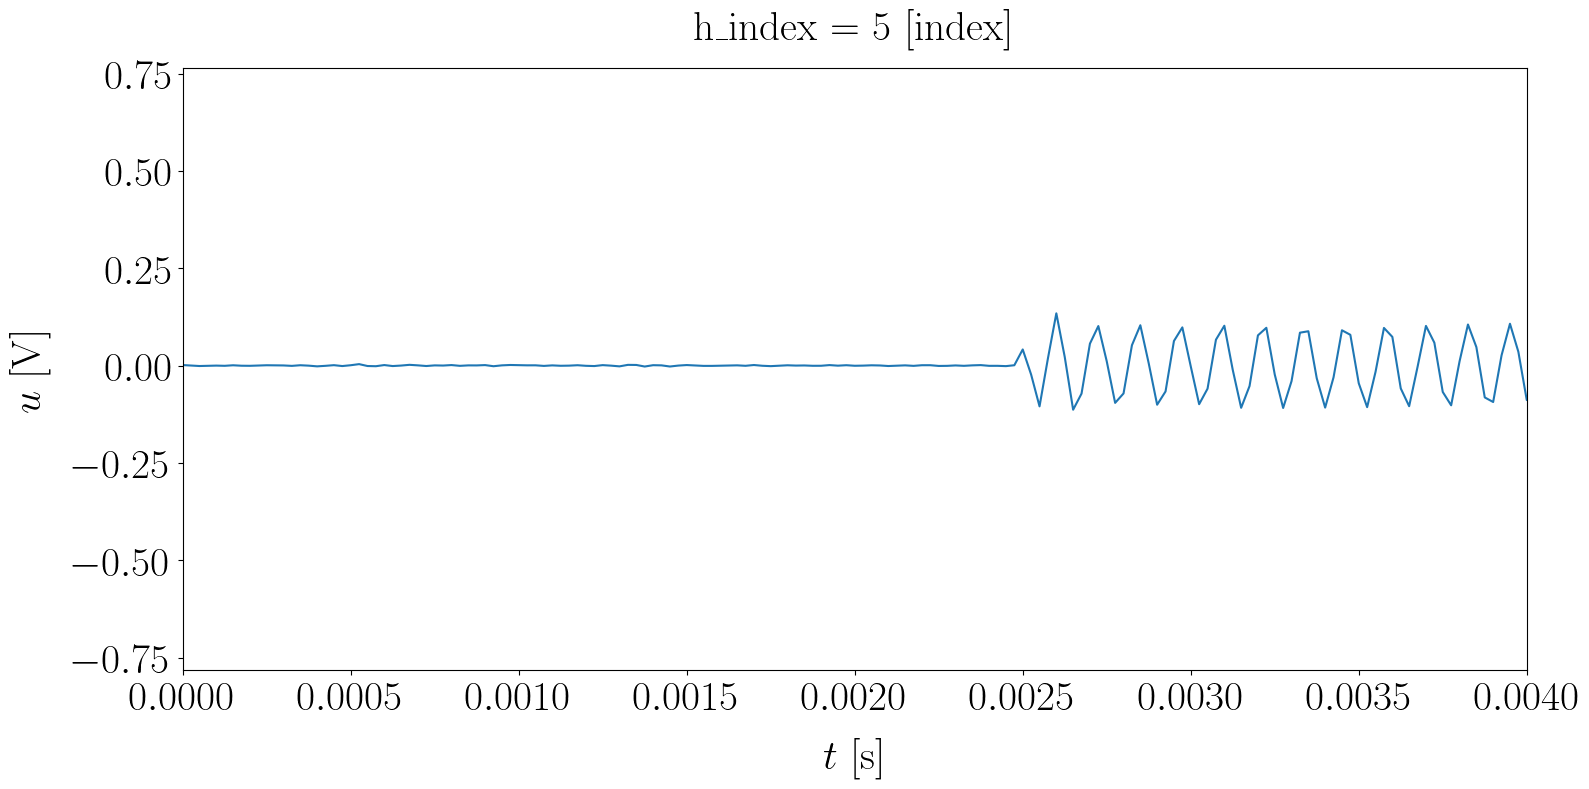

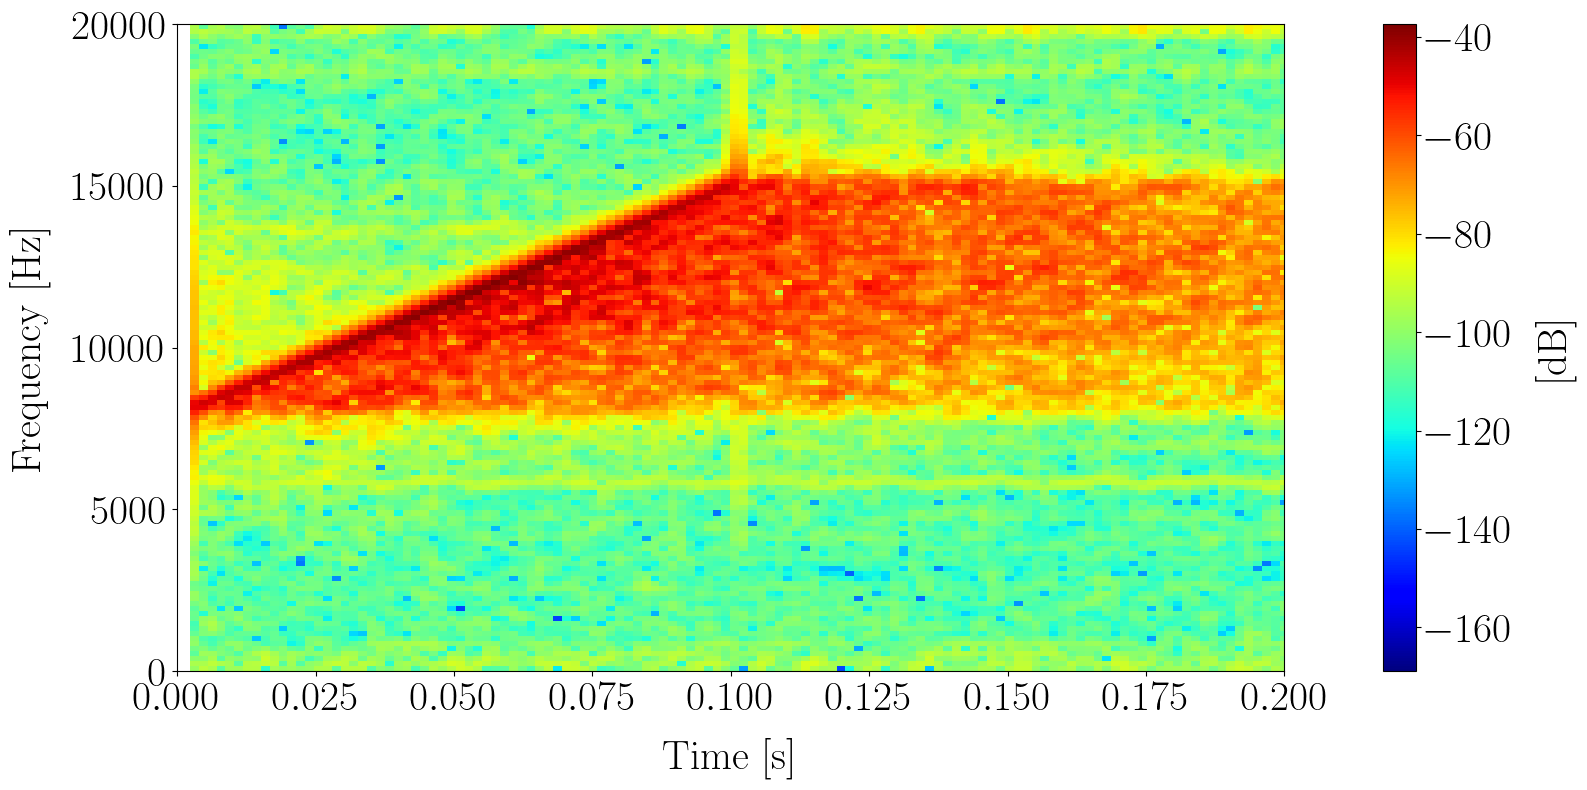

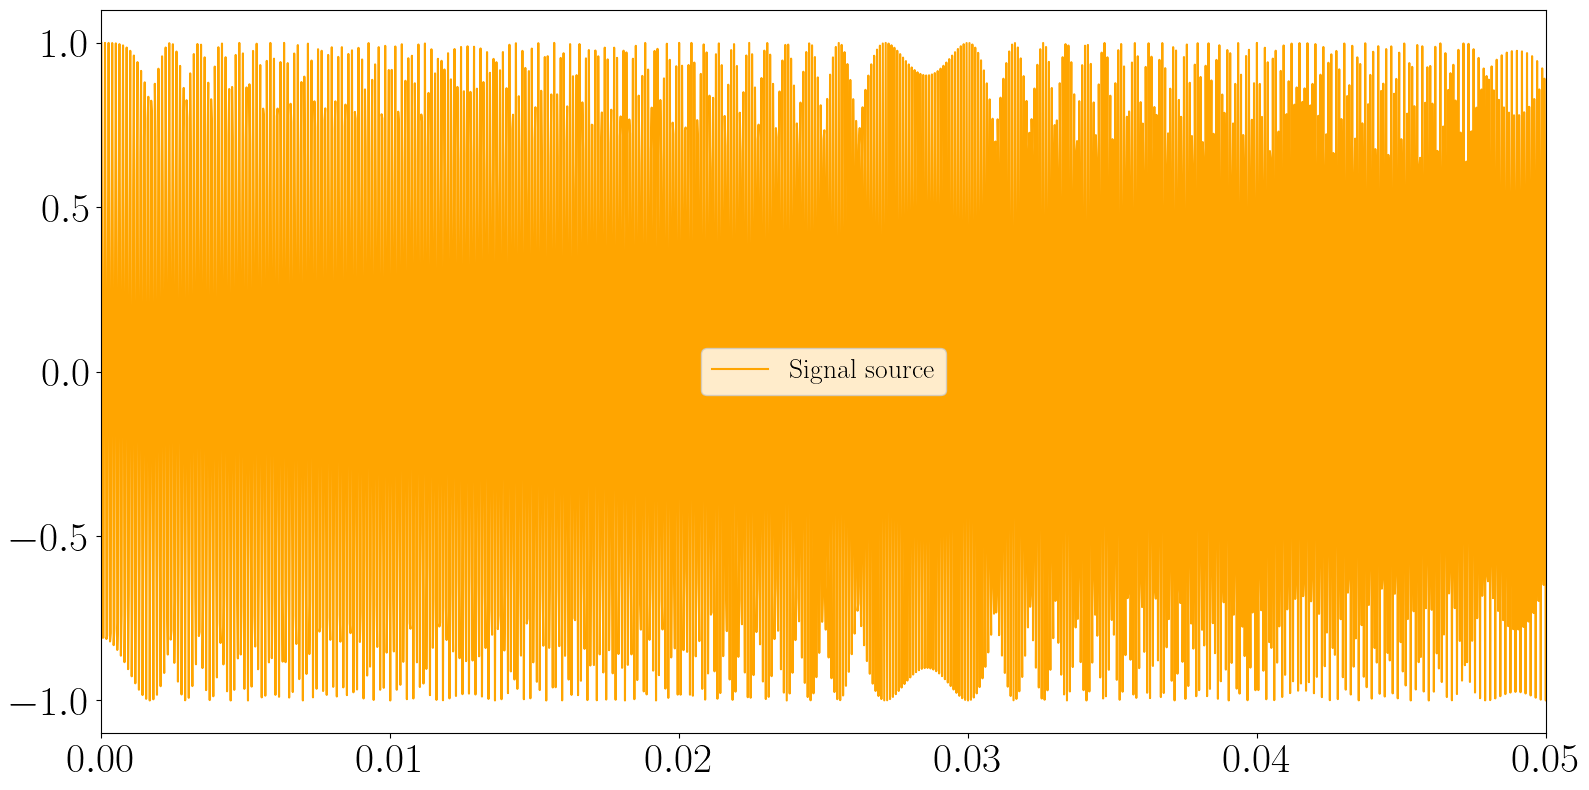

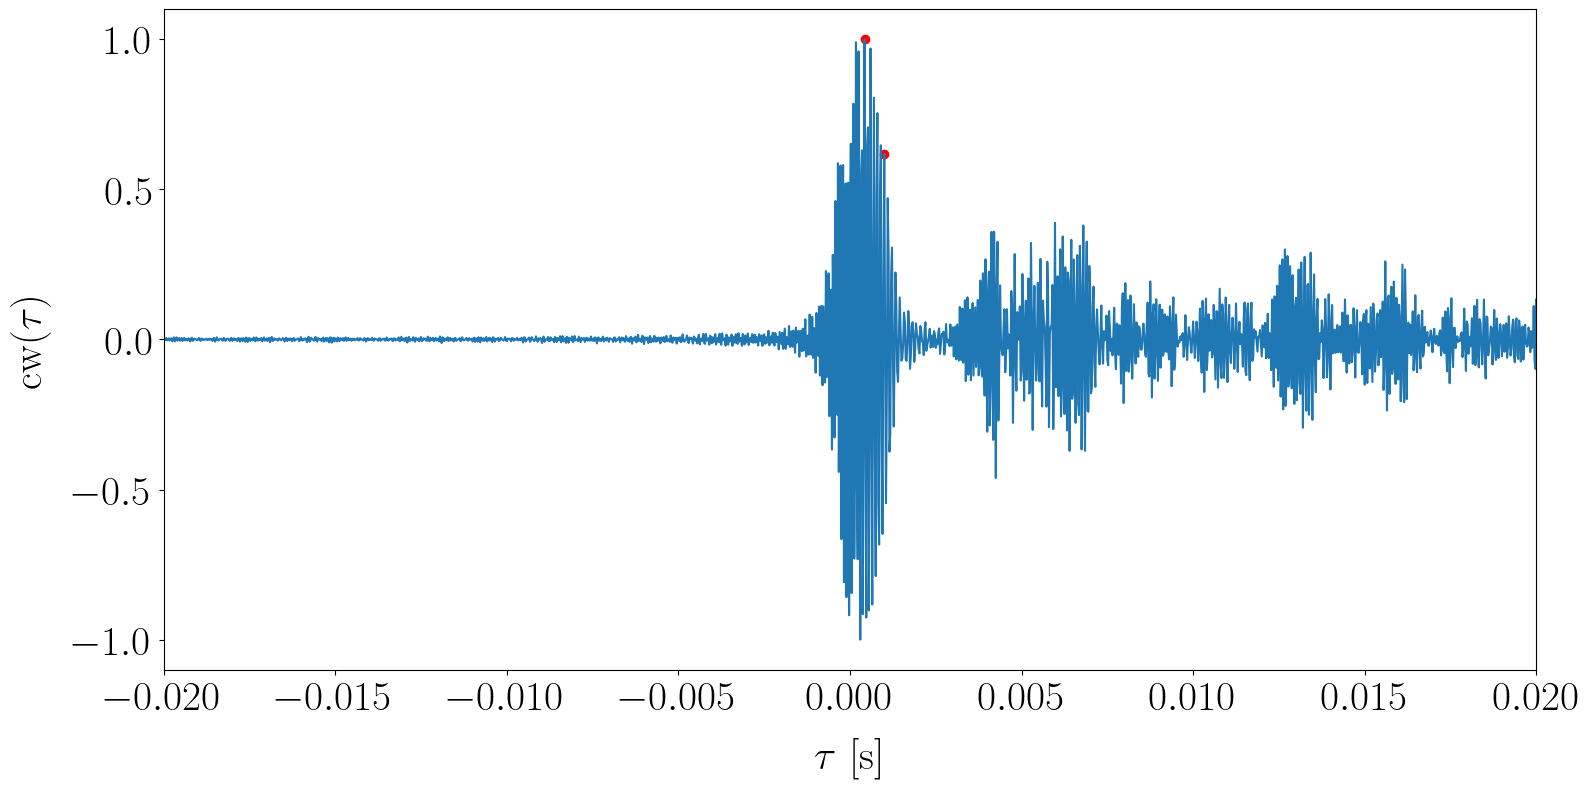

In [36]:


sig.plot()
plt.xlim([0, 0.004])


# Plot signal spectrogram
nstft = 2**8
nov = int(nstft * 0.75)
plt.figure()
plt.specgram(sig.values, NFFT=nstft, Fs=ds_rtf.fs, noverlap=nov, cmap="jet")
plt.colorbar(label="[dB]")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.xlim([0, 0.2])

# Calcul de l'intercorrélation avec le signal source
t_pulse = fs_sweep.pulse_length
t = sig.sel(time=slice(0, t_pulse)).time.values
f0 = fs_sweep.fmin
f1 = fs_sweep.fmax
sig_source = sp.chirp(t, f0=f0, f1=f1, t1=t_pulse, method="linear")

# Plot sig source
plt.figure()
plt.plot(t, sig_source, label="Signal source", color="orange")
plt.xlim([0, 0.05])
plt.legend()

# corr = np.correlate(sig.values, sig_source, mode="full")
# # Normalize
# corr = corr / np.max(np.abs(corr))
x = sig.values
y = sig_source
corr = sp.correlate(x, y, mode="full")
corr = corr / np.max(np.abs(corr))

lags = sp.correlation_lags(x.size, y.size, mode="full")


# lags = np.arange(-len(sig_source) + 1, len(sig))
corr_time = lags / ds_rtf.fs
plt.figure()
plt.plot(corr_time, corr)
plt.xlim([-0.02, 0.02])
plt.xlabel(r"$\tau$ [s]")
plt.ylabel(r"cw($\tau$)")
# Find peaks in the correlation
# dist_peaks = int(1/2*fs_sweep.interp_pulse_period * ds_rtf.fs)
dist_peaks = int(0.0005 * ds_rtf.fs)
# peaks, properties = sp.find_peaks(corr, height=0.45, distance=dist_peaks)

# Limit peaks detection to positive corr_time
idx_positive = corr_time >= 0
corr_positive = corr[idx_positive]
corr_time_positive = corr_time[idx_positive]
peaks, properties = sp.find_peaks(corr_positive, height=0.45, distance=dist_peaks)


# Plot the peaks
plt.scatter(corr_time_positive[peaks], corr_positive[peaks], color="red")

td = corr_time_positive[peaks[0]]
print(f"Time of arrival (direct) = {td} s")
d = td * 1500
print(f"Distance (direct) = {d} m")

# # Store
# for i in range(len(peaks)):
#     print(f"Pulse n° {i+1}")
#     td = corr_time[peaks[i]] - i * fs_sweep.interp_pulse_period
#     print(f"Time of arrival (direct) = {td} s")
#     d = td * 1500
#     print(f"Distance (direct) = {d} m")

In [34]:
4/1500

0.0026666666666666666

### Estimation des positions des hydro par moindre carrés non linéaires 

In [132]:
# Estimation du temps de propagation direct pour chacune des positions de la sources et pour chacun des hydrophones
# Pour le récepteur j et la position P1 : dj = (rj**2 + zj**2)**0.5

# Define the source signal
t_pulse = fs_sweep.pulse_length
tr = fs_sweep.interp_pulse_period
n_sweep = fs_sweep.n_sweep
t = sig.sel(time=slice(0, t_pulse)).time.values
f0 = fs_sweep.fmin
f1 = fs_sweep.fmax
sig_source = sp.chirp(t, f0=f0, f1=f1, t1=t_pulse, method="linear")

c0 = 1500

idx_peak = 0

# mode = "first_pulse"
# mode = "each_pulse"
# mode = "sum_cw"
mode = "env_detect"

# Init dictionnary
src_pos_labels = np.unique([record_name.split("_")[-4] for record_name in records_to_process])
rcv_labels = [f"H{idx_rcv}" for idx_rcv in ds_rtf.h_index.values]
obs = {
    rcv_l: {src_pos_l: {"td": [], "d": []} for src_pos_l in src_pos_labels}
    for rcv_l in rcv_labels
}


# obs[rcv_label][src_pos_label] = {
#     "td": [],
#     "d": []
# }

for idx_rcv in ds_rtf.h_index.values:

    # Iterate overs source positions
    for record_name in records_to_process:
        # Load data
        ds_rtf_fpath = os.path.join(p.root_data, "static", f"{record_name}_rtf.nc")
        ds_rtf = xr.open_dataset(ds_rtf_fpath)

        # Get received signal
        sig = ds_rtf.signal.sel(h_index=idx_rcv)

        src_pos_label = record_name.split("_")[-4]
        rcv_label = f"H{idx_rcv}"

        # Approach 0 : Use only first emission
        if mode == "first_pulse":
            sig_pulse = sig.sel(time=slice(2*tr, (2+1)*tr))

            # Derive inter-correlation with the source signal
            x = sig_pulse.values
            y = sig_source
            corr = sp.correlate(x, y, mode="full")
            corr = corr / np.max(np.abs(corr))

            lags = sp.correlation_lags(x.size, y.size, mode="full")
            corr_time = lags / ds_rtf.fs
            # print(corr_time)
            # Find peaks in the correlation
            dist_peaks = int(0.0005 * ds_rtf.fs)
            # peaks, properties = sp.find_peaks(corr, height=0.45, distance=dist_peaks)

            # Limit peaks detection to positive corr_time
            idx_positive = corr_time >= 0
            corr_positive = corr[idx_positive]
            corr_time_positive = corr_time[idx_positive]
            peaks, properties = sp.find_peaks(corr_positive, height=0.45, distance=dist_peaks)

            td = corr_time_positive[peaks[idx_peak]]
            d = td * c0
            # print(f"Time of arrival (direct) = {td} s")
            # print(f"Distance (direct) = {d} m")

            # Store results
            obs[rcv_label][src_pos_label]["td"].append(td)
            obs[rcv_label][src_pos_label]["d"].append(d)

        # Approach 1 : detect each pulse arrivals -> lead to exact same td (no more info = not more robust)
        if mode == "each_pulse":
            for ipulse in range(n_sweep):
                sig_pulse = sig.sel(time=slice(ipulse*tr, (ipulse+1)*tr))
                # print(sig_pulse.time)

                # Derive inter-correlation with the source signal
                x = sig_pulse.values
                y = sig_source
                corr = sp.correlate(x, y, mode="full")
                corr = corr / np.max(np.abs(corr))

                lags = sp.correlation_lags(x.size, y.size, mode="full")
                corr_time = lags / ds_rtf.fs
                # print(corr_time)
                # Find peaks in the correlation
                dist_peaks = int(0.0005 * ds_rtf.fs)
                # peaks, properties = sp.find_peaks(corr, height=0.45, distance=dist_peaks)

                # Limit peaks detection to positive corr_time
                idx_positive = corr_time >= 0
                corr_positive = corr[idx_positive]
                corr_time_positive = corr_time[idx_positive]
                peaks, properties = sp.find_peaks(corr_positive, height=0.45, distance=dist_peaks)

                td = corr_time_positive[peaks[idx_peak]]
                d = td * c0
                # print(f"Time of arrival (direct) = {td} s")
                # print(f"Distance (direct) = {d} m")

                # Store results
                obs[rcv_label][src_pos_label]["td"].append(td)
                obs[rcv_label][src_pos_label]["d"].append(d)

        # Approach 2 : detect direct arrival on the sum of pulse after compression
        elif mode == "sum_cw":
            sig_pulse_0 = sig.sel(time=slice(0 * tr, (0 + 1) * tr))
            sig_cw = sig_pulse_0.values[:-1]
            for ipulse in range(1, n_sweep):
                # print(ipulse)
                sig_pulse = sig.sel(time=slice(ipulse * tr, (ipulse + 1) * tr))
                sig_cw += sig_pulse.values
            # plt.figure()
            # plt.plot(sig_pulse_0.time[:-1], sig_cw)
            # plt.show()
            # Derive inter-correlation with the source signal
            x = sig_cw
            y = sig_source
            corr = sp.correlate(x, y, mode="full")
            corr = corr / np.max(np.abs(corr))

            lags = sp.correlation_lags(x.size, y.size, mode="full")
            corr_time = lags / ds_rtf.fs
            # print(corr_time)
            # Find peaks in the correlation
            dist_peaks = int(0.0005 * ds_rtf.fs)
            # peaks, properties = sp.find_peaks(corr, height=0.45, distance=dist_peaks)

            # Limit peaks detection to positive corr_time
            idx_positive = corr_time >= 0
            corr_positive = corr[idx_positive]
            corr_time_positive = corr_time[idx_positive]
            peaks, properties = sp.find_peaks(
                corr_positive, height=0.45, distance=dist_peaks
            )

            td = corr_time_positive[peaks[idx_peak]]
            d = td * c0
            # print(f"Time of arrival (direct) = {td} s")
            # print(f"Distance (direct) = {d} m")

            # Store results
            obs[rcv_label][src_pos_label]["td"].append(td)
            obs[rcv_label][src_pos_label]["d"].append(d)

        # Approach 3 : simple enveloppe detector
        elif mode == "env_detect":
            sig_pulse_0 = sig.sel(time=slice(0 * tr, (0 + 1) * tr))

            # Calcul de l'enveloppe
            sig_env = np.abs(sp.hilbert(sig_pulse_0))

            # On défini un seuil à 500 % du niveau de bruit
            c0 = 1500
            d_min = 2
            td_min = d_min / c0
            noise_lvl = sig_env[0 : int(td_min * fs)].max()
            env_detection_th = 5 * noise_lvl

            # Recherche du premier pic au dessus du seuil
            idx_peak = np.where(sig_env > env_detection_th)[0][0]
            # On définit un intervalle de reherche autour du pic
            delta_idx_peak = 10
            idx_search_start = max(0, idx_peak - delta_idx_peak)
            idx_search_stop = min(len(sig_env), idx_peak + delta_idx_peak)

            # On calcul la dérivée de l'enveloppe pour trouver le maximum
            ts = 1 / fs
            sig_env_deriv = np.gradient(sig_env, ts)
            idx_peak_refined = (
                np.argmax(sig_env_deriv[idx_search_start:idx_search_stop]) + idx_search_start
            )
            td = sig_pulse_0.time[idx_peak_refined].values
            d = td * c0
            # print(f"Time of arrival (direct) = {td} s")
            # print(f"Distance (direct) = {d} m")

            # Store results
            obs[rcv_label][src_pos_label]["td"].append(td)
            obs[rcv_label][src_pos_label]["d"].append(d)


print(obs)

# Convert to np arrays in the right order in order to use it in the least-squares
d_obs = {rcv_label: [] for rcv_label in obs.keys()}
t_obs = {rcv_label: [] for rcv_label in obs.keys()}

# Define the order based on the source position : from closest to farthest
dict_th_pos = p.dict_th_pos
all_dists = np.array([dict_th_pos[pos] for pos in dict_th_pos.keys()])
idx_pos_sort = np.argsort(all_dists)
src_labels = list(dict_th_pos.keys())
src_label_sorted = [src_labels[i] for i in idx_pos_sort]

for rcv_label in d_obs.keys():
    d_obs_rcv = []
    t_obs_rcv = []
    for src_label in src_label_sorted:
        d_obs_rcv.append(obs[rcv_label][src_label]["d"])
        t_obs_rcv.append(obs[rcv_label][src_label]["td"])

    d_obs[rcv_label] = np.array(d_obs_rcv)
    t_obs[rcv_label] = np.array(t_obs_rcv)

{'H1': {'P1': {'td': [array(0.003575)], 'd': [5.362499999999955]}, 'P2': {'td': [array(0.009425)], 'd': [14.137499999999884]}, 'P3': {'td': [array(0.017925)], 'd': [26.887499999999783]}, 'P4': {'td': [array(0.0192)], 'd': [28.799999999999763]}, 'P5': {'td': [array(0.015225)], 'd': [22.83749999999981]}, 'P6': {'td': [array(0.006325)], 'd': [9.487499999999923]}}, 'H2': {'P1': {'td': [array(0.00265)], 'd': [3.9749999999999677]}, 'P2': {'td': [array(0.007525)], 'd': [11.287499999999907]}, 'P3': {'td': [array(0.016225)], 'd': [24.337499999999803]}, 'P4': {'td': [array(0.01915)], 'd': [28.724999999999767]}, 'P5': {'td': [array(0.013725)], 'd': [20.58749999999983]}, 'P6': {'td': [array(0.004575)], 'd': [6.862499999999944]}}, 'H3': {'P1': {'td': [array(0.00305)], 'd': [4.574999999999963]}, 'P2': {'td': [array(0.0057)], 'd': [8.54999999999993]}, 'P3': {'td': [array(0.012125)], 'd': [18.18749999999985]}, 'P4': {'td': [array(0.015275)], 'd': [22.91249999999981]}, 'P5': {'td': [array(0.008775)], '

In [133]:
hydro_to_position = "H1"
# Inital guess for H1 (relative to P1)
# D'après le doc de valérie sur les données Fiberscope la source en P1 est située entre H2 et H3 (plus proche de H2) et à une immersion d'environ 4m
# La profondeur du bassin est de 10 m et les hydrophones sont situés envirion 40/50 cm au dessus du fond -> H1 à z ~ 9.5m - 4 de P1
# L'espace entre les hydrophones est de 3m -> H1 à r ~ 4 de P1
r1 = 4
z1 = 4.1
drp = 5

dr_hydro = 3

if hydro_to_position == "H1":
    x0 = [-r1, z1, drp]
elif hydro_to_position == "H2":
    x0 = [-(r1 - dr_hydro), z1, drp]
elif hydro_to_position == "H3":
    x0 = [-(2*dr_hydro-r1), z1, drp]
elif hydro_to_position == "H4":
    x0 = [-(3 * dr_hydro - r1), z1, drp]
elif hydro_to_position == "H5":
    x0 = [-r1, 0, drp]

x_init = np.array(x0)

In [134]:
d_obs[hydro_to_position], t_obs[hydro_to_position]

(array([[ 5.3625],
        [ 9.4875],
        [14.1375],
        [22.8375],
        [26.8875],
        [28.8   ]]),
 array([[0.003575],
        [0.006325],
        [0.009425],
        [0.015225],
        [0.017925],
        [0.0192  ]]))

In [135]:
# Option : utilisation de la fonctio scipy.optimize.least_squares
dr_p = 5  # m  # Distance between two succesive positions of the source (Pi)       (We assume all position are at the same immersion zs)
zh = 4.1    # Assume the z coords of hydrophones 

# Model function y_k = f_k(r, z)
def model_function(x, k):
    r = x        # Parameters to estimate
    d = np.sqrt(((k-1)*dr_p - r)**2 + zh**2)
    return d

def jac(x, k):
        pass


# Residuals function (needed for scipy.optimize.least_squares)
def fun(x, t, y):
    return model_function(x, t) - y


x0 = x_init[0:1]

# Single measurement per pos
# obs = d_obs[hydro_to_position]
# t = np.arange(len(obs))
# One measurement per pulse
obs = d_obs[hydro_to_position].flatten()
t = np.array([[k+1] * d_obs[hydro_to_position].shape[1] for k in range(d_obs[hydro_to_position].shape[0])]).flatten()       # j in [1, 6] -> id of Pj
res_lsq = least_squares(fun, x0, args=(t, obs), jac="3-point")

In [136]:
res_lsq

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 9.610e-01  1.149e+00  1.234e+00 -2.604e+00 -1.737e+00
                1.295e+00]
           x: [-4.814e+00]
        cost: 7.618211386426594
         jac: [[-7.613e-01]
               [-9.227e-01]
               [-9.638e-01]
               [-9.793e-01]
               [-9.866e-01]
               [-9.907e-01]]
        grad: [ 3.542e-07]
  optimality: 3.5417964927564327e-07
 active_mask: [ 0.000e+00]
        nfev: 5
        njev: 5

In [137]:
# Option : utilisation de la fonctio scipy.optimize.least_squares
dr_p = 5  # m  # Distance between two succesive positions of the source (Pi)       (We assume all position are at the same immersion zs)

# Model function y_k = f_k(r, z)
def model_function(x, k):
    r, z = x        # Parameters to estimate
    d = np.sqrt(((k-1) * dr_p - r)**2 + z**2)
    return d

def jac(x, k):
        pass


# Residuals function (needed for scipy.optimize.least_squares)
def fun(x, t, y):
    return model_function(x, t) - y

# H1
# Initial guess
# D'après le coument de valérie sur les données Fiberscope la source en P1 est située entre H2 et H3 (plus proche de H2) et à une immersion d'environ 4m
# La profondeur du bassin est de 10 m et les hydrophones sont situés envirion 40/50 cm au dessus du fond -> H1 à z ~ 9.5m - 4 de P1
# L'espace entre les hydrophones est de 3m -> H1 à r ~ 4 de P1
# x0 = [4, 4.1]
x0 = x_init[0:2]

# Single measurement per pos
# obs = d_obs[hydro_to_position]
# t = np.arange(len(obs))
# One measurement per pulse
obs = d_obs[hydro_to_position].flatten()
t = np.array(
    [
        [k + 1] * d_obs[hydro_to_position].shape[1]
        for k in range(d_obs[hydro_to_position].shape[0])
    ]
).flatten()  # j in [1, 6] -> id of Pj
res_lsq = least_squares(fun, x0, args=(t, obs), jac="3-point")

In [138]:
res_lsq

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 5.625e-02  9.313e-01  1.281e+00 -2.419e+00 -1.469e+00
                1.619e+00]
           x: [-5.419e+00  3.932e-05]
        cost: 6.56996093754646
         jac: [[-1.000e+00  7.257e-06]
               [-1.000e+00  3.774e-06]
               [-1.000e+00  2.550e-06]
               [-1.000e+00  1.926e-06]
               [-1.000e+00  1.547e-06]
               [-1.000e+00  1.293e-06]]
        grad: [-2.079e-06  2.353e-06]
  optimality: 2.353295810880416e-06
 active_mask: [ 0.000e+00  0.000e+00]
        nfev: 14
        njev: 7

In [139]:
x_hat = res_lsq.x
print(f"Least-squares solution for {hydro_to_position}: r, z = {x_hat}")

Least-squares solution for H1: r, z = [-5.41875035e+00  3.93238761e-05]


Bilan : résultats médiocres 
Suite : intégration de l'espace inter-position de la source dr_p comme paramètre du pb de moindres carrés

In [161]:
# Model function y_k = f_k(r, dr_p)
def model_function(x, k):
    r, dr = x  # Parameters to estimate
    d = np.sqrt(((k-1)*dr - r) ** 2 + z1**2)
    return d

def jac(x, t):
    pass

# Residuals function (needed for scipy.optimize.least_squares)
def fun(x, t, y):
    return model_function(x, t) - y

# H1
# Initial guess
# D'après le coument de valérie sur les données Fiberscope la source en P1 est située entre H2 et H3 (plus proche de H2) et à une immersion d'environ 4m
# La profondeur du bassin est de 10 m et les hydrophones sont situés envirion 40/50 cm au dessus du fond -> H1 à z ~ 9.5m - 4 de P1
# L'espace entre les hydrophones est de 3m -> H1 à r ~ 4 de P1
# x0 = [4, 4.1, 5]
# x0 = [4+3, 4.5, 5]
x0 = [x_init[0], x_init[2]]

# Single measurement per pos
# obs = d_obs[hydro_to_position]
# t = np.arange(len(obs))
# One measurement per pulse
obs = d_obs[hydro_to_position].flatten()
t = np.array(
    [
        [k + 1] * d_obs[hydro_to_position].shape[1]
        for k in range(d_obs[hydro_to_position].shape[0])
    ]
).flatten()  # j in [1, 6] -> id of Pj
res_lsq = least_squares(fun, x0, args=(t, obs), jac="3-point", ftol=1e-8)

In [162]:
res_lsq

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 3.051e-01  6.245e-01  1.002e+00 -2.515e+00 -1.321e+00
                2.039e+00]
           x: [-3.913e+00  5.331e+00]
        cost: 6.859279988298866
         jac: [[-6.904e-01  0.000e+00]
               [-9.141e-01  9.141e-01]
               [-9.626e-01  1.925e+00]
               [-9.794e-01  2.938e+00]
               [-9.871e-01  3.948e+00]
               [-9.911e-01  4.956e+00]]
        grad: [-1.290e-07  2.620e-08]
  optimality: 1.2898372581116035e-07
 active_mask: [ 0.000e+00  0.000e+00]
        nfev: 4
        njev: 4

In [168]:
# Compare to apriori positions
x_ap = [x_init[0], x_init[2]]
r_ap, dr_ap = x_ap

# Compute distance to each src pos
d_ap = [model_function(x=x_ap, k=j) for j in range(1, 7)]

# Derived distance
x_hat = res_lsq.x
d_hat = [model_function(x=x_hat, k=j) for j in range(1, 7)]

print(f"Distance apriori : {d_ap}")
print(f"Observed distance : {obs}")
print(f"Modeled distance : {d_hat}")

Distance apriori : [5.728001396647874, 9.889893831583835, 14.588008774332431, 19.43733520830466, 24.347689828811273, 29.28839360565888]
Observed distance : [ 5.3625  9.4875 14.1375 22.8375 26.8875 28.8   ]
Modeled distance : [5.667553416865552, 10.111987090524488, 15.13978082594635, 20.32248024600592, 25.566051759975732, 30.839461104096245]


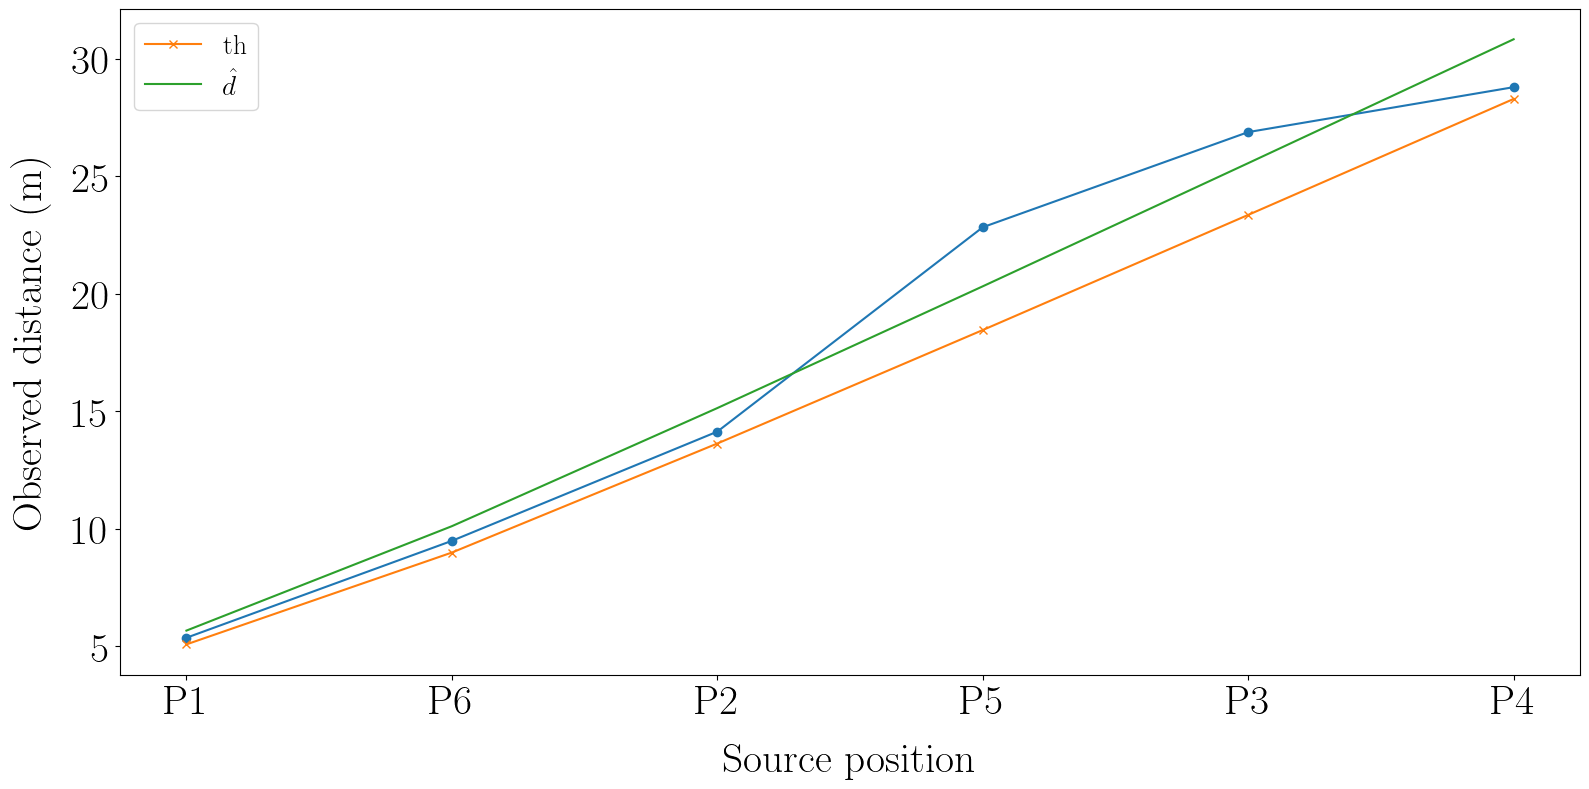

In [169]:
# Plot the observed distances for H1
r0 = 3
r_th = all_dists[idx_pos_sort] + r0
z_th = 4.1
th_dist = np.sqrt(r_th**2 + z_th**2)

# Inverted distances
plt.figure()
plt.plot(
    d_obs[hydro_to_position],
    marker="o",
)
plt.plot(th_dist, marker="x", label="th")
plt.plot(d_hat, label=r"$\hat{d}$")
plt.xticks(ticks=np.arange(len(src_label_sorted)), labels=src_label_sorted)
plt.xlabel("Source position")
plt.ylabel("Observed distance (m)")
plt.legend()

Dernière option avec ce schéma : inverser également la célérité 

In [143]:
# Model function y_k = f_k(r, z, dr_p)
def model_function(x, k):
    r, z, dr, c = x  # Parameters to estimate
    d = np.sqrt(((k-1)*dr - r) ** 2 + z**2)
    td = d / c
    return td

def jac(x, t):
    pass

# Residuals function (needed for scipy.optimize.least_squares)
def fun(x, t, y):
    return model_function(x, t) - y

# H1
# Initial guess
# D'après le coument de valérie sur les données Fiberscope la source en P1 est située entre H2 et H3 (plus proche de H2) et à une immersion d'environ 4m
# La profondeur du bassin est de 10 m et les hydrophones sont situés envirion 40/50 cm au dessus du fond -> H1 à z ~ 9.5m - 4 de P1
# L'espace entre les hydrophones est de 3m -> H1 à r ~ 4 de P1
# x0 = [4, 4.1, 5]
# x0 = [4+3, 4.5, 5]
x0 = x_init[0:3]
x0 = np.append(x0, c0)
# Single measurement per pos
# obs = d_obs[hydro_to_position]
# t = np.arange(len(obs))
# One measurement per pulse
obs = t_obs[hydro_to_position].flatten()
t = np.array(
    [
        [k + 1] * d_obs[hydro_to_position].shape[1]
        for k in range(d_obs[hydro_to_position].shape[0])
    ]
).flatten()  # j in [1, 6] -> id of Pj
res_lsq = least_squares(fun, x0, args=(t, obs), jac="3-point", ftol=1e-8)

In [144]:
res_lsq

     message: `gtol` termination condition is satisfied.
     success: True
      status: 1
         fun: [-1.027e-04  5.380e-04  8.289e-04 -1.580e-03 -8.893e-04
                1.227e-03]
           x: [-2.083e+01 -3.731e-01  2.035e+01  6.000e+03]
        cost: 2.88980738840968e-06
         jac: [[-1.666e-04 -2.985e-06  0.000e+00 -5.787e-07]
               [-1.667e-04 -1.510e-06  1.667e-04 -1.144e-06]
               ...
               [-1.667e-04 -6.084e-07  6.667e-04 -2.839e-06]
               [-1.667e-04 -5.074e-07  8.333e-04 -3.404e-06]]
        grad: [-3.546e-09 -2.248e-10  5.152e-09 -2.979e-11]
  optimality: 5.151551084149525e-09
 active_mask: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00]
        nfev: 11
        njev: 5

In [145]:
x_hat = res_lsq.x
print(f"Least-squares solution for {hydro_to_position}: r, z, drp, c0 = {x_hat}")
print(res_lsq.fun*x_hat[-1])

Least-squares solution for H1: r, z, drp, c0 = [-2.08306425e+01 -3.73092107e-01  2.03457104e+01  6.00000114e+03]
[-0.61602068  3.22803592  4.97318384 -9.48139351 -5.33585539  7.35974055]


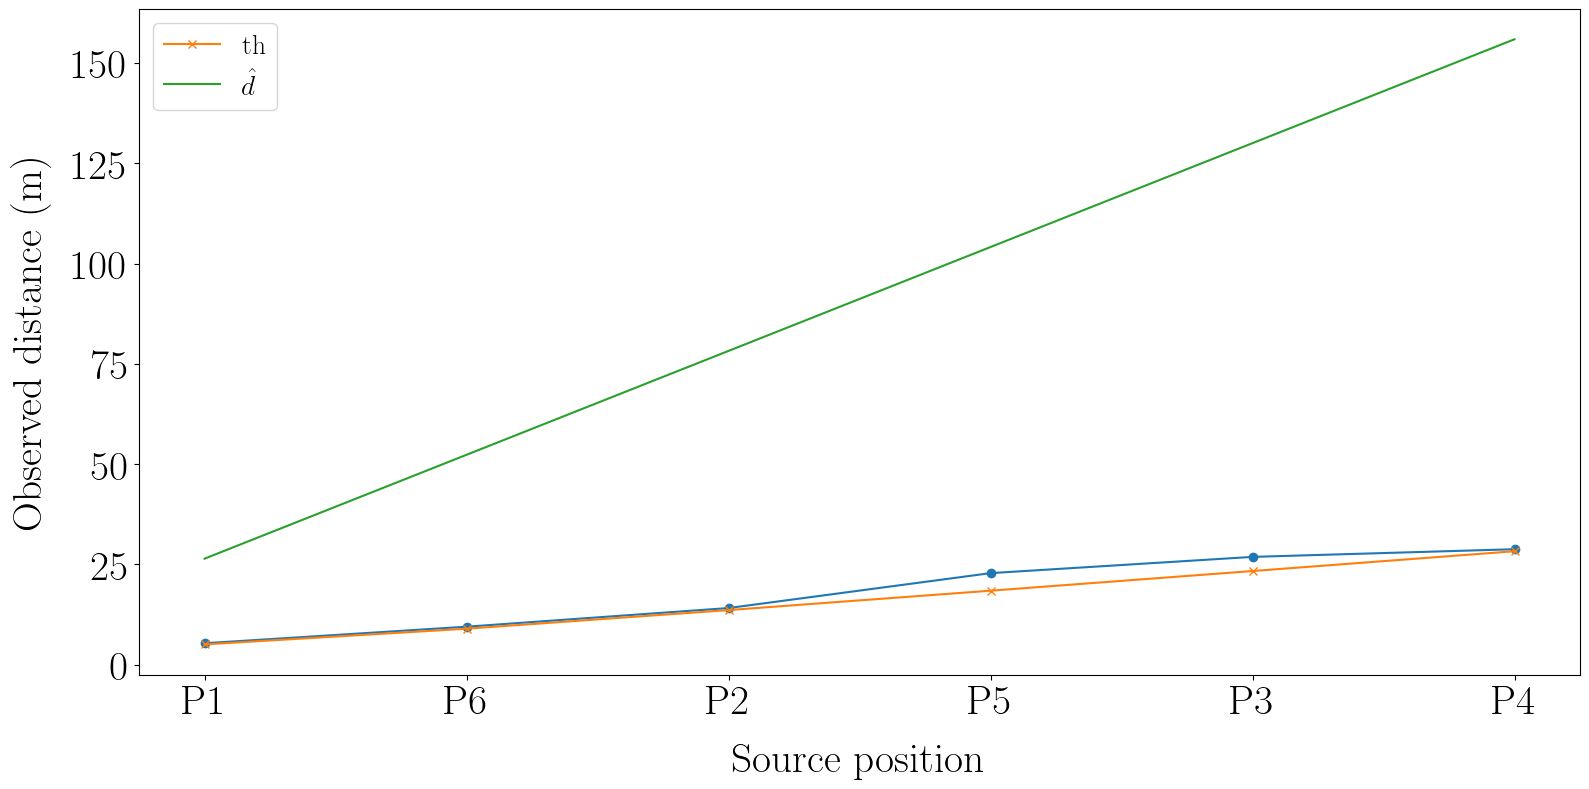

In [159]:
# Plot the observed distances for H1
r0 = 3
r_th = all_dists[idx_pos_sort] + r0
z_th = 4.1
th_dist = np.sqrt(r_th**2 + z_th**2)

# Inverted distances 
tinv = model_function(x=x_hat, k=np.arange(1, len(th_dist)+1))
dinv = x_hat[-1] * tinv
plt.figure()
plt.plot(d_obs[hydro_to_position], marker="o", )
plt.plot(th_dist, marker="x", label="th")
plt.plot(dinv, label=r"$\hat{d}$")
plt.xticks(ticks=np.arange(len(src_label_sorted)), labels=src_label_sorted)
plt.xlabel("Source position")
plt.ylabel("Observed distance (m)")
plt.legend()

### Localisation des hydrophones par TDOA 

On cherche à estimer la position $\begin{pmatrix} r \\ z \end{pmatrix}$ de l'hydrophone, par exemple $H_1$.

On dispose des enregistrements correspondant aux positions de la source de $P_0$ à $P_5$ noté $P_j \begin{pmatrix} r_j \\ z_j \end{pmatrix}$. L'origine du repère est choisie en $P_0$ de telle sorte que $r_j = j \times \Delta_r, z_j = 0$, $j \in [0, 5]$.

Soit $j \in [0, 5]$,

$$
D_j^2 = \lVert P_jH_1\rVert^2 = (r_j - r)^2 + (z-z_j)^2 = (r_j - r)^2 + z^2   
$$

Pour la position de référence (j=0) : 

$$
(1) \quad \quad D_0^2 = (r_0 - r)^2 + z^2 = r_0^2 - 2r_0r + z^2  = z^2
$$

Or on peut écrire pour $j \in [1, 5]$ :

$$
(2) \quad \quad D_j^2 = (D_0 + \delta D_j)^2 = D_0^2 + 2D_0 \delta D_j + D_j^2
$$

Et, 

$$
(3) \quad \quad  D_0^2 + 2D_0 \delta D_j + D_j^2 =  r_j^2 - 2r_jr + z^2 
$$

Ainsi, on peut écrire (3) - (2) : 

$$
(4) \quad \quad  2D_0 \delta D_j + D_j^2 =  r_j^2 - 2r_jr
$$

En pratique on mesure des différences de temps d'arrivée $\delta T_j = T_j - T_0$, $\delta D_j = c \delta T_j$. 

Et donc (4) s'écrit :
$$
(4) \quad \quad  2D_0 c \delta T_j + (c \delta T_j)^2 =  r_j^2 - 2r_jr
$$

On a donc 3 inconnues ($D_0, c, r$) pour 5 équations ($j \in [1, 5]$).



### Minimisation en fonction du paramètres $n_{\rm{stft}}$ 

In [22]:
tau_ir_0 = p.tau_ir
ir_multiplicators = [1, 2, 3, 4, 5]
ov_factors = [0.5, 0.75, 0.9]

# Test only one configuration
ir_multiplicators = [1]
ov_factors = [0.9]

for ir_mult in ir_multiplicators:
    for ov_factor in ov_factors:
        print(f"IR multiplicator: {ir_mult}, Overlap factor: {ov_factor}")

        tau_ir = ir_mult * tau_ir_0

        fsm = FiberscopeManager(
            root_processed_data=p.root_data,
            h_index_ref=h_index_ref,
            tau_ir=tau_ir,
            alpha_overlap=ov_factor,
            plot_feature=True,
        )

        # Load and preprocess static record
        fs_sweep = FiberscopeSweep1()
        fs_sweep.records_folder = os.path.join(p.root_data, "static", f"ir{ir_mult}_ov{int(ov_factor*100)}")
        if not os.path.exists(fs_sweep.records_folder):
            os.makedirs(fs_sweep.records_folder)

        fsm.process_static_analysis(
            static_signal=fs_sweep,
            static_records_names=records_to_process,
        )

        # Compare RTF estimated by deconvolution and by CS-EVD
        for record_name in records_to_process:
            ds_rtf_fpath = os.path.join(
                fs_sweep.records_folder, f"{record_name}_rtf.nc"
            )
            ds_rtf = xr.open_dataset(ds_rtf_fpath)

            # Build RTF ref (from deconvolution)
            rtf_ref = ds_rtf.rtf_amp * np.exp(1j*ds_rtf.rtf_phase)

            # Build RTF hat (from CS-EVD)
            rtf_hat = ds_rtf.rtf_amp_hat * np.exp(1j * ds_rtf.rtf_phase_hat)

            # Interp RTF ref at RTF hat frequencies (nearest neigbor)
            rtf_ref = rtf_ref.sel(f_ir=rtf_hat.f_rtf.values, method="nearest")

            # Compute mean theta distance over the frequency band of interest
            theta = dist_func(rtf_ref=rtf_ref.values, rtf=rtf_hat.values, **dist_kwargs)

            print(f"Record: {record_name}")
            print(theta)      

IR multiplicator: 1, Overlap factor: 0.9
Record: 09-10-2024T10-34-58-394627_P1_N1_Sweep_34
39.70246114366101
Record: 09-10-2024T16-51-22-900122_P2_N1_Sweep_93
38.96393874441961
Record: 10-10-2024T09-43-06-620681_P3_N1_Sweep_151
43.33470961175968
Record: 10-10-2024T12-03-02-201689_P4_N1_Sweep_211
39.73157839361119
Record: 10-10-2024T14-42-01-833325_P5_N2_Sweep_267
56.280766652917784
Record: 10-10-2024T15-54-25-737795_P6_N1_Sweep_323
38.18149001832937
